# Emotional Drift Analysis of Tourism Reviews

## MSc Thesis Analysis

This notebook analyzes how the emotional composition of tourism reviews changes over time from 2019 to 2024.

Input:
- `Tourism_Reviews_Emotion.csv`

The dataset contains review-level probabilities for seven emotions:

- Anger
- Disgust
- Fear
- Joy
- Neutral
- Sadness
- Surprise

The main objective is to aggregate these review-level emotions by month and city, measure month-to-month emotional drift, detect significant changes, and compare patterns across tourism destinations.

Import libraries

In [1]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import cosine, jensenshannon

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Load Emotion Dataset

The review-level emotion dataset generated in `EmotionAnalysis.ipynb` is used as the input for this analysis.

In [2]:
# ============================================================
# STEP 2: LOAD EMOTION DATASET
# ============================================================

file_path = "Tourism_Reviews_Emotion.csv"

df = pd.read_csv(
    file_path,
    encoding="utf-8-sig"
)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Dataset loaded successfully.
Rows: 22092
Columns: 30


,City,Place,Page,Review_Text,Review_Date,Reviewer_Location,Rating,Year,Month,Month_Year,Rating_Valid,Model_Text,Clean_Text,Language,Is_English,Word_Count,Language_Status,Language_Final,Review_ID,Translated_Text,Translation_Status,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise,Dominant_Emotion,Dominant_Emotion_Score
0,Agra,Taj Mahal,0,An amazing experience,2019-02-17,Unknown,5,2019,2,2019-02,True,An amazing experience,an amazing experience,ro,False,3,detected,en,R000001,An amazing experience,Not Required,0.005210,0.003741,0.030083,0.485461,0.052319,0.008267,0.414919,joy,0.485461
1,Agra,Taj Mahal,0,Awesome place,2019-02-17,"Dharmendra Pahadiya Pune, India",5,2019,2,2019-02,True,Awesome place,awesome place,unknown,False,2,unknown_short,en,R000002,Awesome place,Not Required,0.003087,0.002857,0.003248,0.797196,0.060793,0.003041,0.129778,joy,0.797196
2,Agra,Taj Mahal,0,Definitely a wonder of the world,2019-02-17,Unknown,5,2019,2,2019-02,True,Definitely a wonder of the world,definitely a wonder of the world,en,True,6,detected,en,R000003,Definitely a wonder of the world,Not Required,0.004154,0.002859,0.006706,0.015445,0.052878,0.002578,0.915380,surprise,0.915380
3,Agra,Taj Mahal,0,Mesmerizing,2019-02-16,Unknown,5,2019,2,2019-02,True,Mesmerizing,mesmerizing,unknown,False,1,unknown_short,it,R000004,Mesmerizing,Processed,0.015222,0.049447,0.011290,0.022652,0.864298,0.023749,0.013341,neutral,0.864298
4,Agra,Taj Mahal,0,A place really called as wonder,2019-02-16,Unknown,5,2019,2,2019-02,True,A place really called as wonder,a place really called as wonder,en,True,6,detected,en,R000005,A place really called as wonder,Not Required,0.001923,0.000642,0.003407,0.008736,0.005524,0.001576,0.978191,surprise,0.978191


## Define seven emotion columns

In [3]:
# ============================================================
# EMOTION COLUMNS
# ============================================================

emotion_cols = [
    "Anger",
    "Disgust",
    "Fear",
    "Joy",
    "Neutral",
    "Sadness",
    "Surprise"
]

print(emotion_cols)

['Anger', 'Disgust', 'Fear', 'Joy', 'Neutral', 'Sadness', 'Surprise']


### Validate the input dataset

### Step 3 — Validate Emotion Dataset

Before calculating emotional drift, the review-level emotion dataset is checked for completeness, duplicate IDs, missing emotion probabilities, and temporal coverage.

In [4]:
# ============================================================
# STEP 3A: BASIC VALIDATION
# ============================================================

print("Dataset shape:", df.shape)

print("\nNumber of cities:")
print(df["City"].nunique())

print("\nNumber of attractions:")
print(df["Place"].nunique())

print("\nDuplicate Review_ID values:")
print(df["Review_ID"].duplicated().sum())

print("\nYear range:")
print(df["Year"].min(), "-", df["Year"].max())

Dataset shape: (22092, 30)

Number of cities:
10

Number of attractions:
48

Duplicate Review_ID values:
0

Year range:
2019 - 2024


### Validate emotion columns

In [5]:
# ============================================================
# STEP 3B: VALIDATE EMOTION SCORES
# ============================================================

missing_emotion_columns = [
    col
    for col in emotion_cols
    if col not in df.columns
]

print("Missing emotion columns:", missing_emotion_columns)

print("\nMissing emotion scores:")
print(df[emotion_cols].isna().sum())

print("\nEmotion score ranges:")

for col in emotion_cols:
    print(
        f"{col}: "
        f"min={df[col].min():.6f}, "
        f"max={df[col].max():.6f}"
    )

Missing emotion columns: []

Missing emotion scores:
Anger       0
Disgust     0
Fear        0
Joy         0
Neutral     0
Sadness     0
Surprise    0
dtype: int64

Emotion score ranges:
Anger: min=0.000445, max=0.958461
Disgust: min=0.000231, max=0.988454
Fear: min=0.000222, max=0.992318
Joy: min=0.000201, max=0.992623
Neutral: min=0.000565, max=0.973489
Sadness: min=0.000862, max=0.988439
Surprise: min=0.000476, max=0.984807


### Verify probabilities sum to 1

In [6]:
# ============================================================
# STEP 3C: CHECK EMOTION PROBABILITY SUM
# ============================================================

df["Emotion_Sum"] = df[emotion_cols].sum(axis=1)

print(df["Emotion_Sum"].describe())

count    2.209200e+04
mean     1.000000e+00
std      5.269302e-08
min      9.999998e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: Emotion_Sum, dtype: float64


In [7]:
print(
    "Rows far from probability sum 1:",
    (~np.isclose(df["Emotion_Sum"], 1.0, atol=1e-4)).sum()
)

Rows far from probability sum 1: 0


### Check Reviews Without Usable Model Text

Although all reviews contain emotion probabilities, reviews without usable model text should be identified because emotion predictions generated from empty text do not represent meaningful review content.

In [8]:
# ============================================================
# CHECK EMPTY MODEL TEXT
# ============================================================

empty_text_mask = (
    df["Model_Text"].isna()
    |
    df["Model_Text"]
      .fillna("")
      .astype(str)
      .str.strip()
      .eq("")
)

print("Reviews without usable Model_Text:", empty_text_mask.sum())

display(
    df.loc[
        empty_text_mask,
        [
            "Review_ID",
            "City",
            "Place",
            "Review_Date",
            "Model_Text",
            "Anger",
            "Disgust",
            "Fear",
            "Joy",
            "Neutral",
            "Sadness",
            "Surprise"
        ]
    ]
)

Reviews without usable Model_Text: 7


,Review_ID,City,Place,Review_Date,Model_Text,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
12270,R012271,Bali,Sacred Monkey Forest Sanctuary,2023-08-20,NaN,0.064134,0.104007,0.051363,0.040564,0.549477,0.11169,0.078766
12488,R012489,Bali,Sacred Monkey Forest Sanctuary,2019-11-09,NaN,0.064134,0.104007,0.051363,0.040564,0.549477,0.11169,0.078766
13183,R013184,Bali,Mount Batur,2024-07-18,NaN,0.064134,0.104007,0.051363,0.040564,0.549477,0.11169,0.078766
15751,R015752,Paris,Eiffel Tower,2021-08-03,NaN,0.064134,0.104007,0.051363,0.040564,0.549477,0.11169,0.078766
16925,R016926,Paris,Notre-Dame Cathedral,2020-12-26,NaN,0.064134,0.104007,0.051363,0.040564,0.549477,0.11169,0.078766
18927,R018928,Rio de Janeiro,Ipanema Beach,2019-11-23,NaN,0.064134,0.104007,0.051363,0.040564,0.549477,0.11169,0.078766
20331,R020332,Rome,Colosseum,2023-07-16,NaN,0.064134,0.104007,0.051363,0.040564,0.549477,0.11169,0.078766


### Exclude Reviews Without Usable Text

Seven reviews contain no usable `Model_Text` but have emotion probabilities generated by the emotion-classification model. Since these predictions are not based on meaningful review text, these records are excluded from the emotional drift analysis.

The original input CSV is not modified.

In [9]:
# ============================================================
# EXCLUDE REVIEWS WITHOUT USABLE MODEL TEXT
# ============================================================

df = df.loc[~empty_text_mask].copy()

df.reset_index(drop=True, inplace=True)

print("Reviews retained for emotional drift analysis:", len(df))
print("Reviews excluded:", empty_text_mask.sum())

Reviews retained for emotional drift analysis: 22085
Reviews excluded: 7


## Step 4 — Prepare the Temporal Variable

The `Month_Year` variable is converted into a proper datetime format to ensure that monthly emotional profiles are arranged in chronological order.

This is necessary for calculating emotional changes between consecutive months.

In [10]:
# ============================================================
# STEP 4: PREPARE TEMPORAL VARIABLE
# ============================================================

df["Month_Year"] = pd.to_datetime(
    df["Month_Year"].astype(str),
    format="%Y-%m",
    errors="coerce"
)

print("Missing Month_Year:", df["Month_Year"].isna().sum())
print("First month:", df["Month_Year"].min())
print("Last month:", df["Month_Year"].max())

Missing Month_Year: 0
First month: 2019-01-01 00:00:00
Last month: 2024-12-01 00:00:00


### Create monthly emotional profiles

## Step 5 — Create Monthly Emotion Profiles

The review-level emotion probabilities are aggregated by `City` and `Month_Year`.

For each city-month, the number of reviews and the mean probability of each of the seven emotions are calculated.

Each city-month is therefore represented by a seven-dimensional emotional profile:

**[Anger, Disgust, Fear, Joy, Neutral, Sadness, Surprise]**

These monthly emotional profiles will later be compared across consecutive months to measure emotional drift.

In [11]:
# ============================================================
# STEP 5: CREATE MONTHLY EMOTION PROFILES
# ============================================================

monthly = (
    df
    .groupby(["City", "Month_Year"])
    .agg(
        Review_Count=("Review_ID", "count"),

        Anger=("Anger", "mean"),
        Disgust=("Disgust", "mean"),
        Fear=("Fear", "mean"),
        Joy=("Joy", "mean"),
        Neutral=("Neutral", "mean"),
        Sadness=("Sadness", "mean"),
        Surprise=("Surprise", "mean")
    )
    .reset_index()
    .sort_values(["City", "Month_Year"])
    .reset_index(drop=True)
)

print("Number of monthly city profiles:", len(monthly))
print("Number of cities:", monthly["City"].nunique())

display(monthly.head(20))

Number of monthly city profiles: 675
Number of cities: 10


,City,Month_Year,Review_Count,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
0,Agra,2019-01-01,10,0.008636,0.015231,0.027535,0.290578,0.371770,0.131628,0.154622
1,Agra,2019-02-01,146,0.041761,0.043144,0.035883,0.304585,0.300946,0.059196,0.214485
2,Agra,2019-03-01,67,0.032286,0.057432,0.035815,0.361505,0.293344,0.078165,0.141452
3,Agra,2019-04-01,22,0.021959,0.031777,0.054882,0.247863,0.436471,0.045278,0.161770
4,Agra,2019-05-01,38,0.044525,0.073250,0.093308,0.342015,0.208124,0.071224,0.167553
5,Agra,2019-06-01,41,0.019999,0.030665,0.094473,0.268283,0.356589,0.032469,0.197521
6,Agra,2019-07-01,26,0.052796,0.046592,0.061628,0.322515,0.248977,0.081838,0.185654
7,Agra,2019-08-01,22,0.021654,0.038795,0.059089,0.344298,0.330776,0.072002,0.133385
8,Agra,2019-09-01,20,0.051316,0.065852,0.061593,0.340829,0.306555,0.016885,0.156971
9,Agra,2019-10-01,19,0.057725,0.019298,0.034781,0.179132,0.517429,0.115154,0.076481


### Step 6 — First validate the monthly profiles

### Validate Monthly Emotion Profiles

After monthly aggregation, the seven mean emotion probabilities should still form an emotional distribution whose total is approximately 1.

This check confirms that the monthly emotional profiles are valid before calculating emotional drift.

In [16]:
# ============================================================
# STEP 6A: VALIDATE MONTHLY EMOTION PROFILES
# ============================================================

monthly["Emotion_Total"] = monthly[emotion_cols].sum(axis=1)

print("Monthly emotion profile validation:")
print(monthly["Emotion_Total"].describe())

print(
    "\nProfiles far from probability sum 1:",
    (~np.isclose(
        monthly["Emotion_Total"],
        1.0,
        atol=1e-4
    )).sum()
)

Monthly emotion profile validation:
count    6.750000e+02
mean     1.000000e+00
std      1.469181e-08
min      9.999999e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: Emotion_Total, dtype: float64

Profiles far from probability sum 1: 0


### Examine Monthly Review Counts

The number of reviews varies between city-months. Months with very few reviews may produce unstable estimates of the monthly emotional profile.

The distribution of monthly review counts is therefore examined before selecting a minimum review threshold.

In [17]:
# ============================================================
# STEP 6B: MONTHLY REVIEW COUNT DISTRIBUTION
# ============================================================

print("Monthly review count statistics:")

print(
    monthly["Review_Count"].describe()
)

print("\nCity-months with fewer than 5 reviews:",
      (monthly["Review_Count"] < 5).sum())

print("City-months with fewer than 10 reviews:",
      (monthly["Review_Count"] < 10).sum())

print("City-months with fewer than 20 reviews:",
      (monthly["Review_Count"] < 20).sum())

Monthly review count statistics:
count    675.000000
mean      32.718519
std       30.867442
min        1.000000
25%       13.000000
50%       25.000000
75%       41.000000
max      213.000000
Name: Review_Count, dtype: float64

City-months with fewer than 5 reviews: 49
City-months with fewer than 10 reviews: 124
City-months with fewer than 20 reviews: 267


### Compare Minimum Review Thresholds

Thresholds of 5, 10, and 20 reviews per city-month are compared.

The purpose is to balance two requirements:

1. **Reliability** — monthly profiles should contain enough reviews.
2. **Temporal coverage** — too strict a threshold may remove a large part of the time series.

The final threshold will therefore be selected based on both coverage and robustness rather than chosen arbitrarily.

In [18]:
# ============================================================
# STEP 6C: COMPARE REVIEW THRESHOLDS
# ============================================================

threshold_results = []

for threshold in [5, 10, 20]:

    valid = monthly[
        monthly["Review_Count"] >= threshold
    ]

    threshold_results.append({
        "Minimum_Reviews": threshold,
        "Valid_City_Months": len(valid),
        "Removed_City_Months": len(monthly) - len(valid),
        "Coverage_Percentage":
            round(
                len(valid) / len(monthly) * 100,
                2
            )
    })

threshold_table = pd.DataFrame(threshold_results)

display(threshold_table)

,Minimum_Reviews,Valid_City_Months,Removed_City_Months,Coverage_Percentage
0,5,626,49,92.74
1,10,551,124,81.63
2,20,408,267,60.44


### Threshold Coverage by City

The effect of the minimum review threshold is examined separately for each city.

This is important because a global threshold may retain sufficient data for some cities while removing a large number of months from others.

Thresholds of 5, 10, and 20 reviews are therefore compared at the city level before selecting the primary threshold.

In [19]:
# ============================================================
# STEP 6D: THRESHOLD COVERAGE BY CITY
# ============================================================

coverage_records = []

for city in monthly["City"].unique():

    city_data = monthly[
        monthly["City"] == city
    ]

    total_observed_months = len(city_data)

    for threshold in [5, 10, 20]:

        valid_months = (
            city_data["Review_Count"] >= threshold
        ).sum()

        coverage_records.append({
            "City": city,
            "Threshold": threshold,
            "Observed_Months": total_observed_months,
            "Valid_Months": valid_months,
            "Coverage_Percentage": round(
                valid_months / total_observed_months * 100,
                2
            )
        })

coverage_df = pd.DataFrame(coverage_records)

coverage_table = coverage_df.pivot(
    index="City",
    columns="Threshold",
    values="Valid_Months"
)

coverage_table.columns = [
    "Months_ge_5",
    "Months_ge_10",
    "Months_ge_20"
]

display(coverage_table)

,Months_ge_5,Months_ge_10,Months_ge_20
City,,,
Agra,63,46,18
Bali,57,51,38
Barcelona,61,51,37
Cairo,68,59,35
Dubai,67,64,57
Marrakech,53,49,43
Miami,71,68,50
Paris,61,54,47
Rio de Janeiro,66,56,35


In [20]:
# ============================================================
# STEP 6E: COMPLETE MONTHLY COVERAGE BY CITY
# ============================================================

city_coverage = (
    monthly
    .groupby("City")
    .agg(
        Observed_Months=("Month_Year", "nunique"),
        Total_Reviews=("Review_Count", "sum")
    )
    .reset_index()
)

city_coverage["Expected_Months"] = 72

city_coverage["Missing_Months"] = (
    city_coverage["Expected_Months"]
    - city_coverage["Observed_Months"]
)

display(city_coverage)

,City,Observed_Months,Total_Reviews,Expected_Months,Missing_Months
0,Agra,69,1342,72,3
1,Bali,70,2131,72,2
2,Barcelona,66,2725,72,6
3,Cairo,69,1770,72,3
4,Dubai,67,2949,72,5
5,Marrakech,65,2438,72,7
6,Miami,72,2201,72,0
7,Paris,63,2368,72,9
8,Rio de Janeiro,70,1752,72,2
9,Rome,64,2409,72,8


## Step 7 — Select the Primary Monthly Review Threshold

Monthly emotional profiles based on very small numbers of reviews may be unstable. Therefore, minimum thresholds of 5, 10, and 20 reviews per city-month were evaluated.

The results showed:

- ≥5 reviews retained 92.74% of observed city-months.
- ≥10 reviews retained 81.63% of observed city-months.
- ≥20 reviews retained only 60.44% of observed city-months.

A minimum threshold of **10 reviews per city-month** was selected for the primary emotional drift analysis as a compromise between temporal coverage and the stability of monthly emotion estimates.

The thresholds of 5 and 20 reviews will later be used in sensitivity analysis to evaluate whether the main drift findings are robust to the threshold choice.

In [21]:
# ============================================================
# STEP 7: APPLY PRIMARY REVIEW THRESHOLD
# ============================================================

PRIMARY_THRESHOLD = 10

monthly_valid = monthly[
    monthly["Review_Count"] >= PRIMARY_THRESHOLD
].copy()

monthly_valid = monthly_valid.sort_values(
    ["City", "Month_Year"]
).reset_index(drop=True)

print("Primary threshold:", PRIMARY_THRESHOLD)
print("Original observed city-months:", len(monthly))
print("Valid city-months:", len(monthly_valid))
print("Removed low-sample city-months:",
      len(monthly) - len(monthly_valid))

print(
    "Coverage retained:",
    round(len(monthly_valid) / len(monthly) * 100, 2),
    "%"
)

Primary threshold: 10
Original observed city-months: 675
Valid city-months: 551
Removed low-sample city-months: 124
Coverage retained: 81.63 %


## Step 8 — Identify Consecutive Valid Months

Emotional drift is intended to measure change between consecutive calendar months.

After applying the minimum review threshold, some months may be missing because they either contain no reviews or do not meet the minimum sample requirement.

Therefore, the previous valid observation is identified for each city and the calendar-month gap is calculated.

For the primary month-to-month drift analysis, only observations with a gap of exactly one month are considered consecutive.

In [22]:
# ============================================================
# STEP 8A: IDENTIFY PREVIOUS VALID MONTH
# ============================================================

monthly_valid["Previous_Month"] = (
    monthly_valid
    .groupby("City")["Month_Year"]
    .shift(1)
)

monthly_valid["Month_Gap"] = (
    (
        monthly_valid["Month_Year"].dt.year * 12
        + monthly_valid["Month_Year"].dt.month
    )
    -
    (
        monthly_valid["Previous_Month"].dt.year * 12
        + monthly_valid["Previous_Month"].dt.month
    )
)

display(
    monthly_valid[
        [
            "City",
            "Month_Year",
            "Previous_Month",
            "Month_Gap",
            "Review_Count"
        ]
    ].head(20)
)

,City,Month_Year,Previous_Month,Month_Gap,Review_Count
0,Agra,2019-01-01,NaT,NaN,10
1,Agra,2019-02-01,2019-01-01,1.0,146
2,Agra,2019-03-01,2019-02-01,1.0,67
3,Agra,2019-04-01,2019-03-01,1.0,22
4,Agra,2019-05-01,2019-04-01,1.0,38
5,Agra,2019-06-01,2019-05-01,1.0,41
6,Agra,2019-07-01,2019-06-01,1.0,26
7,Agra,2019-08-01,2019-07-01,1.0,22
8,Agra,2019-09-01,2019-08-01,1.0,20
9,Agra,2019-10-01,2019-09-01,1.0,19


In [23]:
# ============================================================
# STEP 8B: CHECK TEMPORAL GAPS
# ============================================================

gap_summary = (
    monthly_valid["Month_Gap"]
    .value_counts()
    .sort_index()
)

print("Month-gap distribution:")
print(gap_summary)

consecutive_count = (
    monthly_valid["Month_Gap"] == 1
).sum()

gap_count = (
    monthly_valid["Month_Gap"] > 1
).sum()

print("\nConsecutive month comparisons:", consecutive_count)
print("Comparisons containing a gap:", gap_count)

Month-gap distribution:
Month_Gap
1.0     479
2.0      37
3.0       9
4.0       3
5.0       7
6.0       2
11.0      2
15.0      1
17.0      1
Name: count, dtype: int64

Consecutive month comparisons: 479
Comparisons containing a gap: 62


## Step 9 — Construct Consecutive-Month Comparisons

After applying the minimum threshold of 10 reviews per city-month, 479 observations have a valid immediately preceding calendar month.

These consecutive month pairs are used for the primary emotional drift analysis.

Comparisons with gaps greater than one month are excluded from the primary month-to-month drift calculation because they represent changes across multiple months rather than a single monthly transition.

In [24]:
# ============================================================
# STEP 9: KEEP CONSECUTIVE MONTH COMPARISONS
# ============================================================

consecutive = monthly_valid[
    monthly_valid["Month_Gap"] == 1
].copy()

print("Consecutive month comparisons:", len(consecutive))

display(
    consecutive[
        [
            "City",
            "Previous_Month",
            "Month_Year",
            "Month_Gap",
            "Review_Count"
        ]
    ].head(20)
)

Consecutive month comparisons: 479


,City,Previous_Month,Month_Year,Month_Gap,Review_Count
1,Agra,2019-01-01,2019-02-01,1.0,146
2,Agra,2019-02-01,2019-03-01,1.0,67
3,Agra,2019-03-01,2019-04-01,1.0,22
4,Agra,2019-04-01,2019-05-01,1.0,38
5,Agra,2019-05-01,2019-06-01,1.0,41
6,Agra,2019-06-01,2019-07-01,1.0,26
7,Agra,2019-07-01,2019-08-01,1.0,22
8,Agra,2019-08-01,2019-09-01,1.0,20
9,Agra,2019-09-01,2019-10-01,1.0,19
11,Agra,2019-12-01,2020-01-01,1.0,13


In [25]:
# ============================================================
# STEP 10: ADD PREVIOUS MONTH EMOTION PROFILE
# ============================================================

for emotion in emotion_cols:
    monthly_valid[f"Previous_{emotion}"] = (
        monthly_valid
        .groupby("City")[emotion]
        .shift(1)
    )

# Also keep previous month's review count
monthly_valid["Previous_Review_Count"] = (
    monthly_valid
    .groupby("City")["Review_Count"]
    .shift(1)
)

# Now keep only true consecutive-month comparisons
consecutive = monthly_valid[
    monthly_valid["Month_Gap"] == 1
].copy()

print("Consecutive comparisons:", len(consecutive))

display(
    consecutive[
        [
            "City",
            "Previous_Month",
            "Month_Year",
            "Previous_Review_Count",
            "Review_Count",
            "Previous_Joy",
            "Joy",
            "Previous_Fear",
            "Fear"
        ]
    ].head(10)
)

Consecutive comparisons: 479


,City,Previous_Month,Month_Year,Previous_Review_Count,Review_Count,Previous_Joy,Joy,Previous_Fear,Fear
1,Agra,2019-01-01,2019-02-01,10.0,146,0.290578,0.304585,0.027535,0.035883
2,Agra,2019-02-01,2019-03-01,146.0,67,0.304585,0.361505,0.035883,0.035815
3,Agra,2019-03-01,2019-04-01,67.0,22,0.361505,0.247863,0.035815,0.054882
4,Agra,2019-04-01,2019-05-01,22.0,38,0.247863,0.342015,0.054882,0.093308
5,Agra,2019-05-01,2019-06-01,38.0,41,0.342015,0.268283,0.093308,0.094473
6,Agra,2019-06-01,2019-07-01,41.0,26,0.268283,0.322515,0.094473,0.061628
7,Agra,2019-07-01,2019-08-01,26.0,22,0.322515,0.344298,0.061628,0.059089
8,Agra,2019-08-01,2019-09-01,22.0,20,0.344298,0.340829,0.059089,0.061593
9,Agra,2019-09-01,2019-10-01,20.0,19,0.340829,0.179132,0.061593,0.034781
11,Agra,2019-12-01,2020-01-01,16.0,13,0.445395,0.121884,0.025123,0.079642


## Step 11 — Calculate Month-to-Month Emotional Drift

Each valid city-month is represented as a seven-dimensional emotion probability distribution:

**[Anger, Disgust, Fear, Joy, Neutral, Sadness, Surprise]**

The emotional profile of each month is compared with the immediately preceding valid calendar month.

Two distance measures are calculated:

- **Jensen–Shannon distance** — used as the primary drift measure because the emotion scores form probability distributions.
- **Cosine distance** — used as a complementary robustness measure.

A value close to zero indicates that the emotional composition changed very little, while a larger value indicates stronger emotional change.

In [26]:
# ============================================================
# STEP 11: CALCULATE EMOTIONAL DRIFT
# ============================================================

def calculate_drift(row):

    previous_profile = np.array(
        [row[f"Previous_{emotion}"] for emotion in emotion_cols],
        dtype=float
    )

    current_profile = np.array(
        [row[emotion] for emotion in emotion_cols],
        dtype=float
    )

    js_distance = jensenshannon(
        previous_profile,
        current_profile
    )

    cosine_distance = cosine(
        previous_profile,
        current_profile
    )

    return pd.Series({
        "JS_Drift": js_distance,
        "Cosine_Drift": cosine_distance
    })


consecutive[
    ["JS_Drift", "Cosine_Drift"]
] = consecutive.apply(
    calculate_drift,
    axis=1
)

print("Drift calculation completed.")
print("Number of comparisons:", len(consecutive))

display(
    consecutive[
        [
            "City",
            "Previous_Month",
            "Month_Year",
            "Previous_Review_Count",
            "Review_Count",
            "JS_Drift",
            "Cosine_Drift"
        ]
    ].head(20)
)

Drift calculation completed.
Number of comparisons: 479


,City,Previous_Month,Month_Year,Previous_Review_Count,Review_Count,JS_Drift,Cosine_Drift
1,Agra,2019-01-01,2019-02-01,10.0,146,0.145305,0.030384
2,Agra,2019-02-01,2019-03-01,146.0,67,0.080530,0.018858
3,Agra,2019-03-01,2019-04-01,67.0,22,0.135370,0.065411
4,Agra,2019-04-01,2019-05-01,22.0,38,0.186024,0.122168
5,Agra,2019-05-01,2019-06-01,38.0,41,0.152703,0.066819
6,Agra,2019-06-01,2019-07-01,41.0,26,0.134359,0.039419
7,Agra,2019-07-01,2019-08-01,26.0,22,0.094504,0.019751
8,Agra,2019-08-01,2019-09-01,22.0,20,0.121648,0.011352
9,Agra,2019-09-01,2019-10-01,20.0,19,0.250471,0.149402
11,Agra,2019-12-01,2020-01-01,16.0,13,0.299996,0.300508


## Step 12 — Validate Emotional Drift Scores

Before detecting significant emotional drift, the distributions of Jensen–Shannon and cosine distance are examined.

This step verifies that the calculated distances are valid and provides an overview of the typical magnitude and variability of month-to-month emotional change.

In [27]:
# ============================================================
# STEP 12A: VALIDATE DRIFT SCORES
# ============================================================

print("Number of drift comparisons:", len(consecutive))

print("\nMissing drift values:")
print(
    consecutive[
        ["JS_Drift", "Cosine_Drift"]
    ].isna().sum()
)

print("\nJensen-Shannon drift:")
print(consecutive["JS_Drift"].describe())

print("\nCosine drift:")
print(consecutive["Cosine_Drift"].describe())

Number of drift comparisons: 479

Missing drift values:
JS_Drift        0
Cosine_Drift    0
dtype: int64

Jensen-Shannon drift:
count    479.000000
mean       0.140736
std        0.057867
min        0.024397
25%        0.096038
50%        0.132659
75%        0.177053
max        0.423731
Name: JS_Drift, dtype: float64

Cosine drift:
count    479.000000
mean       0.053518
std        0.054809
min        0.001749
25%        0.017223
50%        0.032744
75%        0.070177
max        0.339413
Name: Cosine_Drift, dtype: float64


In [28]:
# ============================================================
# STEP 12B: DRIFT DISTRIBUTION BY CITY
# ============================================================

city_drift_summary = (
    consecutive
    .groupby("City")
    .agg(
        Comparisons=("JS_Drift", "count"),
        Mean_JS_Drift=("JS_Drift", "mean"),
        Median_JS_Drift=("JS_Drift", "median"),
        Std_JS_Drift=("JS_Drift", "std"),
        Max_JS_Drift=("JS_Drift", "max"),
        Mean_Cosine_Drift=("Cosine_Drift", "mean"),
        Median_Cosine_Drift=("Cosine_Drift", "median"),
        Max_Cosine_Drift=("Cosine_Drift", "max")
    )
    .round(4)
)

display(city_drift_summary)

,Comparisons,Mean_JS_Drift,Median_JS_Drift,Std_JS_Drift,Max_JS_Drift,Mean_Cosine_Drift,Median_Cosine_Drift,Max_Cosine_Drift
City,,,,,,,,
Agra,35,0.1603,0.1527,0.0664,0.3000,0.0806,0.0560,0.3005
Bali,45,0.1419,0.1198,0.0652,0.3039,0.0592,0.0298,0.3046
Barcelona,46,0.1400,0.1308,0.0583,0.2988,0.0592,0.0301,0.2148
Cairo,47,0.1501,0.1422,0.0521,0.2873,0.0560,0.0404,0.3024
Dubai,61,0.1212,0.1148,0.0460,0.2436,0.0386,0.0237,0.2022
Marrakech,45,0.1197,0.1027,0.0564,0.2977,0.0429,0.0206,0.2135
Miami,63,0.1611,0.1511,0.0625,0.4237,0.0622,0.0496,0.3394
Paris,44,0.1279,0.1271,0.0404,0.2722,0.0454,0.0344,0.2565
Rio de Janeiro,49,0.1594,0.1696,0.0630,0.2848,0.0586,0.0473,0.2236


In [30]:
# ============================================================
# STEP 12C: COMPARE THE TWO DRIFT METRICS
# ============================================================

correlation = consecutive[
    ["JS_Drift", "Cosine_Drift"]
].corr()

display(correlation)

,JS_Drift,Cosine_Drift
JS_Drift,1.000000,0.873562
Cosine_Drift,0.873562,1.000000


## Step 13 — Detect Significant Emotional Drift Spikes

The magnitude of normal month-to-month emotional variation differs between cities. Therefore, a single global drift threshold is not used.

Instead, significant drift is detected separately for each city using the Median Absolute Deviation (MAD), a robust measure of variability.

For each city:

1. The median Jensen–Shannon drift is calculated.
2. The absolute deviation of each drift value from the city median is calculated.
3. The median of these deviations gives the MAD.
4. A robust standardized score is calculated.
5. Months with unusually high positive robust scores are flagged as candidate emotional drift spikes.

This approach is less sensitive to extreme observations than methods based on the mean and standard deviation.

In [31]:
# ============================================================
# STEP 13A: CALCULATE CITY-SPECIFIC MEDIAN AND MAD
# ============================================================

def calculate_city_mad(group):

    median_drift = group["JS_Drift"].median()

    mad = np.median(
        np.abs(
            group["JS_Drift"] - median_drift
        )
    )

    group = group.copy()

    group["City_Median_JS"] = median_drift
    group["City_MAD_JS"] = mad

    return group


consecutive = (
    consecutive
    .groupby("City", group_keys=False)
    .apply(calculate_city_mad)
    .reset_index(drop=True)
)

mad_summary = (
    consecutive
    .groupby("City")
    .agg(
        Median_JS_Drift=("City_Median_JS", "first"),
        MAD_JS_Drift=("City_MAD_JS", "first")
    )
    .round(4)
)

display(mad_summary)

C:\Users\vidya\AppData\Local\Temp\ipykernel_26516\642058113.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_city_mad)


,Median_JS_Drift,MAD_JS_Drift
City,,
Agra,0.1527,0.0578
Bali,0.1198,0.0448
Barcelona,0.1308,0.0355
Cairo,0.1422,0.0343
Dubai,0.1148,0.0315
Marrakech,0.1027,0.0291
Miami,0.1511,0.0400
Paris,0.1271,0.0291
Rio de Janeiro,0.1696,0.0507


In [32]:
# ============================================================
# STEP 13B: CALCULATE ROBUST DRIFT SCORE
# ============================================================

consecutive["Robust_Z"] = (
    0.6745
    *
    (
        consecutive["JS_Drift"]
        - consecutive["City_Median_JS"]
    )
    /
    consecutive["City_MAD_JS"]
)

In [33]:
print(
    consecutive["Robust_Z"].describe()
)

count    479.000000
mean       0.135630
std        1.015665
min       -1.938190
25%       -0.599885
50%        0.000000
75%        0.714163
max        4.599706
Name: Robust_Z, dtype: float64


In [34]:
# ============================================================
# STEP 13C: FLAG CANDIDATE DRIFT SPIKES
# ============================================================

SPIKE_THRESHOLD = 3.5

consecutive["Is_Spike"] = (
    consecutive["Robust_Z"]
    > SPIKE_THRESHOLD
)

print(
    "Total drift comparisons:",
    len(consecutive)
)

print(
    "Detected candidate spikes:",
    consecutive["Is_Spike"].sum()
)

print(
    "Spike percentage:",
    round(
        consecutive["Is_Spike"].mean() * 100,
        2
    ),
    "%"
)

Total drift comparisons: 479
Detected candidate spikes: 2
Spike percentage: 0.42 %


In [35]:
# ============================================================
# STEP 13D: DISPLAY DETECTED SPIKES
# ============================================================

spikes = (
    consecutive[
        consecutive["Is_Spike"]
    ]
    .sort_values(
        "JS_Drift",
        ascending=False
    )
    .copy()
)

display(
    spikes[
        [
            "City",
            "Previous_Month",
            "Month_Year",
            "Previous_Review_Count",
            "Review_Count",
            "JS_Drift",
            "Cosine_Drift",
            "City_Median_JS",
            "City_MAD_JS",
            "Robust_Z"
        ]
    ]
)

,City,Previous_Month,Month_Year,Previous_Review_Count,Review_Count,JS_Drift,Cosine_Drift,City_Median_JS,City_MAD_JS,Robust_Z
295,Miami,2020-11-01,2020-12-01,10.0,13,0.423731,0.339413,0.151073,0.039982,4.599706
278,Marrakech,2024-11-01,2024-12-01,23.0,24,0.297725,0.213486,0.102706,0.029080,4.523351


## Step 14 — Explain the Emotional Composition of Each Spike

A high drift score indicates that the overall emotional distribution changed substantially, but it does not identify which emotions were responsible for the change.

Therefore, the change in each emotion probability is calculated as:

**Current Month Emotion − Previous Month Emotion**

Positive values indicate that the emotion increased, while negative values indicate that it decreased.

In [36]:
# ============================================================
# STEP 14A: CALCULATE EMOTION CHANGES
# ============================================================

for emotion in emotion_cols:

    consecutive[f"Delta_{emotion}"] = (
        consecutive[emotion]
        - consecutive[f"Previous_{emotion}"]
    )

In [37]:
spikes = (
    consecutive[
        consecutive["Is_Spike"]
    ]
    .sort_values(
        "JS_Drift",
        ascending=False
    )
    .copy()
)

In [38]:
delta_cols = [
    f"Delta_{emotion}"
    for emotion in emotion_cols
]

display(
    spikes[
        [
            "City",
            "Previous_Month",
            "Month_Year",
            "JS_Drift",
            "Cosine_Drift"
        ]
        + delta_cols
    ]
)

,City,Previous_Month,Month_Year,JS_Drift,Cosine_Drift,Delta_Anger,Delta_Disgust,Delta_Fear,Delta_Joy,Delta_Neutral,Delta_Sadness,Delta_Surprise
295,Miami,2020-11-01,2020-12-01,0.423731,0.339413,0.009391,-0.364703,0.042511,-0.080512,0.157610,0.098560,0.137144
278,Marrakech,2024-11-01,2024-12-01,0.297725,0.213486,0.069699,0.146487,0.065134,-0.266616,-0.030371,0.030587,-0.014920


In [39]:
# ============================================================
# STEP 14B: IDENTIFY DOMINANT EMOTION CHANGE
# ============================================================

def dominant_emotion_change(row):

    changes = {
        emotion: row[f"Delta_{emotion}"]
        for emotion in emotion_cols
    }

    dominant = max(
        changes,
        key=lambda x: abs(changes[x])
    )

    return pd.Series({
        "Dominant_Emotion": dominant,
        "Dominant_Change": changes[dominant]
    })


consecutive[
    [
        "Dominant_Emotion",
        "Dominant_Change"
    ]
] = consecutive.apply(
    dominant_emotion_change,
    axis=1
)

In [40]:
spikes = (
    consecutive[
        consecutive["Is_Spike"]
    ]
    .sort_values(
        "JS_Drift",
        ascending=False
    )
    .copy()
)

In [41]:
display(
    spikes[
        [
            "City",
            "Previous_Month",
            "Month_Year",
            "Review_Count",
            "JS_Drift",
            "Cosine_Drift",
            "Robust_Z",
            "Dominant_Emotion",
            "Dominant_Change"
        ]
    ]
)

,City,Previous_Month,Month_Year,Review_Count,JS_Drift,Cosine_Drift,Robust_Z,Dominant_Emotion,Dominant_Change
295,Miami,2020-11-01,2020-12-01,13,0.423731,0.339413,4.599706,Disgust,-0.364703
278,Marrakech,2024-11-01,2024-12-01,24,0.297725,0.213486,4.523351,Joy,-0.266616


## Step 15 — Spike Detection Sensitivity Analysis

The robust-Z threshold of 3.5 identifies only the most extreme emotional drift observations.

To evaluate whether the detected results depend strongly on this threshold, candidate spike counts are compared using several robust-Z cut-offs.

This analysis is used to distinguish highly conservative spikes from moderately unusual emotional changes. The primary threshold is retained separately from exploratory sensitivity thresholds.

In [42]:
# ============================================================
# STEP 15A: SPIKE THRESHOLD SENSITIVITY
# ============================================================

spike_thresholds = [2.0, 2.5, 3.0, 3.5]

sensitivity_results = []

for threshold in spike_thresholds:

    count = (
        consecutive["Robust_Z"] > threshold
    ).sum()

    sensitivity_results.append({
        "Robust_Z_Threshold": threshold,
        "Detected_Spikes": count,
        "Percentage_of_Transitions": round(
            count / len(consecutive) * 100,
            2
        )
    })

spike_sensitivity = pd.DataFrame(
    sensitivity_results
)

display(spike_sensitivity)

,Robust_Z_Threshold,Detected_Spikes,Percentage_of_Transitions
0,2.0,23,4.80
1,2.5,12,2.51
2,3.0,5,1.04
3,3.5,2,0.42


In [43]:
# ============================================================
# STEP 15B: TOP 20 EMOTIONAL DRIFT TRANSITIONS
# ============================================================

top_drift = (
    consecutive
    .sort_values(
        "JS_Drift",
        ascending=False
    )
    [
        [
            "City",
            "Previous_Month",
            "Month_Year",
            "Previous_Review_Count",
            "Review_Count",
            "JS_Drift",
            "Cosine_Drift",
            "Robust_Z",
            "Dominant_Emotion",
            "Dominant_Change"
        ]
    ]
    .head(20)
)

display(top_drift)

,City,Previous_Month,Month_Year,Previous_Review_Count,Review_Count,JS_Drift,Cosine_Drift,Robust_Z,Dominant_Emotion,Dominant_Change
295,Miami,2020-11-01,2020-12-01,10.0,13,0.423731,0.339413,4.599706,Disgust,-0.364703
57,Bali,2022-11-01,2022-12-01,20.0,68,0.303915,0.304638,2.771473,Joy,0.334752
9,Agra,2019-12-01,2020-01-01,16.0,13,0.299996,0.300508,1.718791,Joy,-0.323511
102,Barcelona,2022-07-01,2022-08-01,78.0,12,0.298757,0.214830,3.195793,Neutral,0.293166
278,Marrakech,2024-11-01,2024-12-01,23.0,24,0.297725,0.213486,4.523351,Joy,-0.266616
10,Agra,2020-01-01,2020-02-01,13.0,123,0.293565,0.255540,1.643741,Neutral,-0.309681
154,Cairo,2023-03-01,2023-04-01,20.0,21,0.287279,0.154717,2.850124,Joy,-0.258351
416,Rio de Janeiro,2023-05-01,2023-06-01,16.0,10,0.284841,0.223632,1.534425,Joy,0.274661
50,Bali,2022-04-01,2022-05-01,19.0,31,0.284201,0.220986,2.474750,Joy,-0.334128
134,Cairo,2020-08-01,2020-09-01,10.0,13,0.283813,0.302430,2.782004,Neutral,-0.307213


## Step 16 — Review-Threshold Robustness Analysis

The primary analysis uses a minimum of 10 reviews per city-month. However, the choice of a minimum review threshold may influence which monthly transitions are available and which emotional drift spikes are detected.

To assess the robustness of the findings, the emotional drift analysis is repeated using minimum monthly review thresholds of:

- 5 reviews
- 10 reviews
- 20 reviews

For each threshold, only consecutive calendar months that satisfy the minimum review requirement in both months are compared.

Jensen–Shannon distance is recalculated, followed by city-specific Median Absolute Deviation (MAD) spike detection using the primary robust-Z threshold of 3.5.

A spike that appears under multiple review thresholds provides stronger evidence that the result is not simply an artifact of the selected monthly sample-size threshold.

In [44]:
# ============================================================
# STEP 16A: REVIEW-THRESHOLD ROBUSTNESS FUNCTION
# ============================================================

def run_drift_analysis(monthly_data, review_threshold, spike_threshold=3.5):

    # 1. Keep months meeting the review threshold
    data = monthly_data[
        monthly_data["Review_Count"] >= review_threshold
    ].copy()

    data = data.sort_values(
        ["City", "Month_Year"]
    ).reset_index(drop=True)

    # 2. Previous valid month
    data["Previous_Month"] = (
        data.groupby("City")["Month_Year"].shift(1)
    )

    # 3. Calendar month gap
    current_month_number = (
        data["Month_Year"].dt.year * 12
        + data["Month_Year"].dt.month
    )

    previous_month_number = (
        data["Previous_Month"].dt.year * 12
        + data["Previous_Month"].dt.month
    )

    data["Month_Gap"] = (
        current_month_number
        - previous_month_number
    )

    # 4. Previous emotion profile
    for emotion in emotion_cols:

        data[f"Previous_{emotion}"] = (
            data.groupby("City")[emotion].shift(1)
        )

    data["Previous_Review_Count"] = (
        data.groupby("City")["Review_Count"].shift(1)
    )

    # 5. Keep only consecutive calendar months
    data = data[
        data["Month_Gap"] == 1
    ].copy()

    # 6. Calculate Jensen-Shannon drift
    def js_for_row(row):

        previous = np.array(
            [
                row[f"Previous_{emotion}"]
                for emotion in emotion_cols
            ],
            dtype=float
        )

        current = np.array(
            [
                row[emotion]
                for emotion in emotion_cols
            ],
            dtype=float
        )

        return jensenshannon(
            previous,
            current
        )

    data["JS_Drift"] = data.apply(
        js_for_row,
        axis=1
    )

    # 7. Calculate city-specific median and MAD
    city_median = (
        data.groupby("City")["JS_Drift"]
        .transform("median")
    )

    data["City_Median_JS"] = city_median

    data["Absolute_Deviation"] = (
        data["JS_Drift"]
        - data["City_Median_JS"]
    ).abs()

    data["City_MAD_JS"] = (
        data.groupby("City")["Absolute_Deviation"]
        .transform("median")
    )

    # 8. Robust Z-score
    data["Robust_Z"] = np.where(
        data["City_MAD_JS"] > 0,
        0.6745
        * (
            data["JS_Drift"]
            - data["City_Median_JS"]
        )
        / data["City_MAD_JS"],
        np.nan
    )

    # 9. Detect extreme spikes
    data["Is_Spike"] = (
        data["Robust_Z"] > spike_threshold
    )

    return data

In [45]:
# ============================================================
# STEP 16B: RUN THRESHOLD SENSITIVITY ANALYSIS
# ============================================================

results_5 = run_drift_analysis(
    monthly,
    review_threshold=5
)

results_10 = run_drift_analysis(
    monthly,
    review_threshold=10
)

results_20 = run_drift_analysis(
    monthly,
    review_threshold=20
)

threshold_robustness = pd.DataFrame({
    "Minimum_Reviews": [5, 10, 20],

    "Consecutive_Comparisons": [
        len(results_5),
        len(results_10),
        len(results_20)
    ],

    "Extreme_Spikes": [
        results_5["Is_Spike"].sum(),
        results_10["Is_Spike"].sum(),
        results_20["Is_Spike"].sum()
    ]
})

threshold_robustness[
    "Spike_Percentage"
] = (
    threshold_robustness["Extreme_Spikes"]
    /
    threshold_robustness["Consecutive_Comparisons"]
    * 100
).round(2)

display(threshold_robustness)

,Minimum_Reviews,Consecutive_Comparisons,Extreme_Spikes,Spike_Percentage
0,5,576,6,1.04
1,10,479,2,0.42
2,20,311,4,1.29


In [46]:
# ============================================================
# STEP 16C: COMPARE DETECTED SPIKES ACROSS THRESHOLDS
# ============================================================

spike_tables = []

for threshold, result in [
    (5, results_5),
    (10, results_10),
    (20, results_20)
]:

    temp = result[
        result["Is_Spike"]
    ].copy()

    temp["Minimum_Reviews"] = threshold

    spike_tables.append(
        temp[
            [
                "Minimum_Reviews",
                "City",
                "Previous_Month",
                "Month_Year",
                "Previous_Review_Count",
                "Review_Count",
                "JS_Drift",
                "Robust_Z"
            ]
        ]
    )


threshold_spikes = pd.concat(
    spike_tables,
    ignore_index=True
)

threshold_spikes = threshold_spikes.sort_values(
    [
        "City",
        "Month_Year",
        "Minimum_Reviews"
    ]
)

display(threshold_spikes)

,Minimum_Reviews,City,Previous_Month,Month_Year,Previous_Review_Count,Review_Count,JS_Drift,Robust_Z
0,5,Agra,2021-07-01,2021-08-01,5.0,8,0.626671,5.657587
8,20,Bali,2022-10-01,2022-11-01,33.0,20,0.256438,4.588531
9,20,Bali,2022-11-01,2022-12-01,20.0,68,0.303915,5.952878
10,20,Cairo,2023-03-01,2023-04-01,20.0,21,0.287279,6.590634
1,5,Marrakech,2024-11-01,2024-12-01,23.0,24,0.297725,4.523351
6,10,Marrakech,2024-11-01,2024-12-01,23.0,24,0.297725,4.523351
11,20,Marrakech,2024-11-01,2024-12-01,23.0,24,0.297725,5.084977
2,5,Miami,2020-04-01,2020-05-01,5.0,10,0.436454,4.710651
3,5,Miami,2020-09-01,2020-10-01,11.0,5,0.410551,4.278984
4,5,Miami,2020-10-01,2020-11-01,5.0,10,0.402031,4.136995


## Step 17 — Evaluate Spike Robustness Across Review Thresholds

Detected spikes are compared across the 5-, 10-, and 20-review thresholds.

A transition appearing as an extreme spike under multiple eligible thresholds provides stronger evidence that the finding is not solely dependent on the selected minimum monthly review count.

Failure to appear at a higher threshold is distinguished from ineligibility caused by insufficient monthly review counts.

In [47]:
# ============================================================
# STEP 17: SPIKE ROBUSTNESS ACROSS REVIEW THRESHOLDS
# ============================================================

spike_presence = (
    threshold_spikes
    .assign(Detected=1)
    .pivot_table(
        index=[
            "City",
            "Previous_Month",
            "Month_Year"
        ],
        columns="Minimum_Reviews",
        values="Detected",
        fill_value=0,
        aggfunc="max"
    )
    .reset_index()
)

spike_presence.columns.name = None

spike_presence = spike_presence.rename(
    columns={
        5: "Spike_ge_5",
        10: "Spike_ge_10",
        20: "Spike_ge_20"
    }
)

for col in ["Spike_ge_5", "Spike_ge_10", "Spike_ge_20"]:
    if col not in spike_presence.columns:
        spike_presence[col] = 0

spike_presence["Thresholds_Detected"] = (
    spike_presence[
        ["Spike_ge_5", "Spike_ge_10", "Spike_ge_20"]
    ].sum(axis=1)
)

spike_presence = spike_presence.sort_values(
    ["Thresholds_Detected", "City"],
    ascending=[False, True]
)

display(spike_presence)

,City,Previous_Month,Month_Year,Spike_ge_5,Spike_ge_10,Spike_ge_20,Thresholds_Detected
4,Marrakech,2024-11-01,2024-12-01,1,1,1,3
8,Miami,2020-11-01,2020-12-01,1,1,0,2
0,Agra,2021-07-01,2021-08-01,1,0,0,1
1,Bali,2022-10-01,2022-11-01,0,0,1,1
2,Bali,2022-11-01,2022-12-01,0,0,1,1
3,Cairo,2023-03-01,2023-04-01,0,0,1,1
5,Miami,2020-04-01,2020-05-01,1,0,0,1
6,Miami,2020-09-01,2020-10-01,1,0,0,1
7,Miami,2020-10-01,2020-11-01,1,0,0,1


## Step 18 — Visualize Monthly Emotional Drift

The primary emotional drift series is visualized using the minimum threshold of 10 reviews per city-month.

Jensen–Shannon distance represents the magnitude of change in the seven-dimensional emotional profile between consecutive calendar months.

Extreme drift spikes identified using the city-specific robust-Z threshold greater than 3.5 are highlighted.

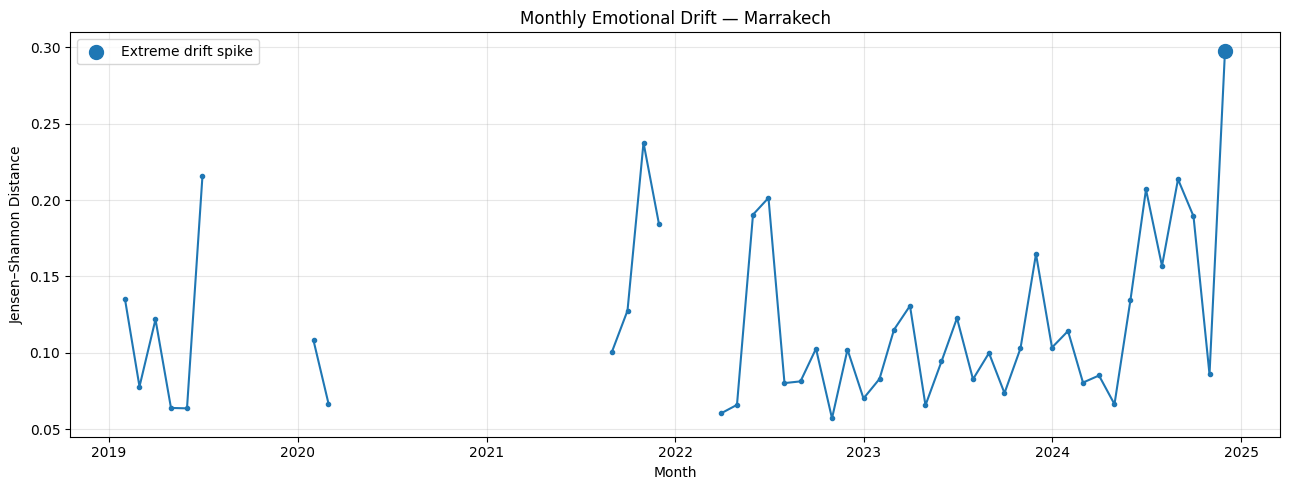

In [49]:
# ============================================================
# STEP 18A: MARRAKECH EMOTIONAL DRIFT
# BREAK LINES ACROSS MISSING / INVALID MONTHS
# ============================================================

city_name = "Marrakech"

city_data = consecutive[
    consecutive["City"] == city_name
].copy()

city_data = city_data.sort_values("Month_Year")

# Create complete monthly timeline
full_months = pd.date_range(
    start=df["Month_Year"].min(),
    end=df["Month_Year"].max(),
    freq="MS"
)

plot_data = (
    city_data
    .set_index("Month_Year")
    .reindex(full_months)
)

# Identify spikes
spike_mask = plot_data["Is_Spike"] == True

plt.figure(figsize=(13, 5))

plt.plot(
    plot_data.index,
    plot_data["JS_Drift"],
    marker="o",
    markersize=3,
    linewidth=1.5
)

plt.scatter(
    plot_data.index[spike_mask],
    plot_data.loc[spike_mask, "JS_Drift"],
    s=100,
    zorder=5,
    label="Extreme drift spike"
)

plt.title(
    f"Monthly Emotional Drift — {city_name}"
)

plt.xlabel("Month")
plt.ylabel("Jensen–Shannon Distance")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

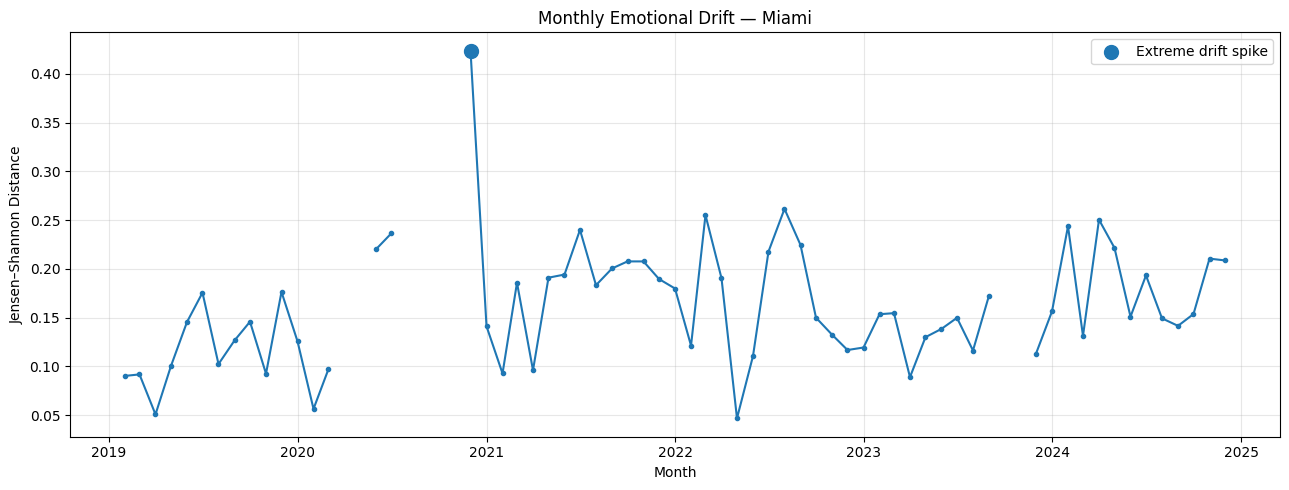

In [50]:
# ============================================================
# STEP 18B: Miami EMOTIONAL DRIFT
# BREAK LINES ACROSS MISSING / INVALID MONTHS
# ============================================================

city_name = "Miami"

city_data = consecutive[
    consecutive["City"] == city_name
].copy()

city_data = city_data.sort_values("Month_Year")

# Create complete monthly timeline
full_months = pd.date_range(
    start=df["Month_Year"].min(),
    end=df["Month_Year"].max(),
    freq="MS"
)

plot_data = (
    city_data
    .set_index("Month_Year")
    .reindex(full_months)
)

# Identify spikes
spike_mask = plot_data["Is_Spike"] == True

plt.figure(figsize=(13, 5))

plt.plot(
    plot_data.index,
    plot_data["JS_Drift"],
    marker="o",
    markersize=3,
    linewidth=1.5
)

plt.scatter(
    plot_data.index[spike_mask],
    plot_data.loc[spike_mask, "JS_Drift"],
    s=100,
    zorder=5,
    label="Extreme drift spike"
)

plt.title(
    f"Monthly Emotional Drift — {city_name}"
)

plt.xlabel("Month")
plt.ylabel("Jensen–Shannon Distance")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 19 — Examine Emotion Trajectories Around Detected Spikes

A drift spike indicates a large change in the overall emotional distribution, but it does not show which emotions produced the change.

To interpret each detected spike, the seven monthly emotion probabilities are examined around the spike period.

This helps determine whether the detected drift represents a temporary fluctuation, a persistent emotional shift, or a reversal in the following months.

In [51]:
# ============================================================
# STEP 19A: MIAMI EMOTION PROFILE AROUND THE SPIKE
# ============================================================

miami_window = monthly_valid[
    (monthly_valid["City"] == "Miami")
    &
    (monthly_valid["Month_Year"] >= "2020-09-01")
    &
    (monthly_valid["Month_Year"] <= "2021-02-01")
].copy()

display(
    miami_window[
        [
            "Month_Year",
            "Review_Count",
            "Anger",
            "Disgust",
            "Fear",
            "Joy",
            "Neutral",
            "Sadness",
            "Surprise"
        ]
    ]
)

,Month_Year,Review_Count,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
338,2020-09-01,11,0.029165,0.121513,0.108159,0.222207,0.373095,0.102121,0.043740
339,2020-11-01,10,0.032497,0.384626,0.005023,0.386478,0.159530,0.010689,0.021158
340,2020-12-01,13,0.041888,0.019923,0.047534,0.305966,0.317139,0.109249,0.158301
341,2021-01-01,22,0.014269,0.043290,0.035933,0.466307,0.232849,0.075547,0.131805
342,2021-02-01,34,0.009565,0.015665,0.017947,0.479041,0.270305,0.109126,0.098351


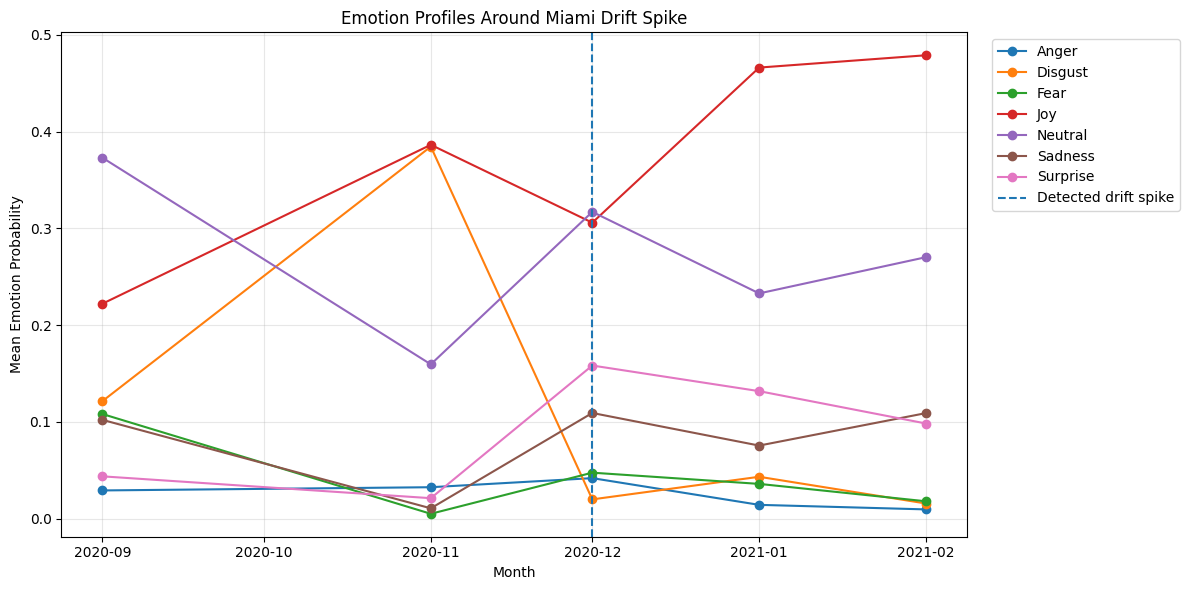

In [52]:
# ============================================================
# STEP 19B: MIAMI EMOTION TRAJECTORIES
# ============================================================

plt.figure(figsize=(12, 6))

for emotion in emotion_cols:
    plt.plot(
        miami_window["Month_Year"],
        miami_window[emotion],
        marker="o",
        label=emotion
    )

plt.axvline(
    pd.Timestamp("2020-12-01"),
    linestyle="--",
    label="Detected drift spike"
)

plt.title(
    "Emotion Profiles Around Miami Drift Spike"
)

plt.xlabel("Month")
plt.ylabel("Mean Emotion Probability")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# STEP 19C: MARRAKECH EMOTION PROFILE AROUND THE SPIKE
# ============================================================

marrakech_window = monthly_valid[
    (monthly_valid["City"] == "Marrakech")
    &
    (monthly_valid["Month_Year"] >= "2024-07-01")
    &
    (monthly_valid["Month_Year"] <= "2024-12-01")
].copy()

display(
    marrakech_window[
        [
            "Month_Year",
            "Review_Count",
            "Anger",
            "Disgust",
            "Fear",
            "Joy",
            "Neutral",
            "Sadness",
            "Surprise"
        ]
    ]
)

,Month_Year,Review_Count,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
314,2024-07-01,27,0.062856,0.033347,0.055398,0.371065,0.255937,0.145004,0.076393
315,2024-08-01,40,0.045246,0.107881,0.067932,0.307829,0.323567,0.058442,0.089104
316,2024-09-01,22,0.080085,0.081835,0.067004,0.259167,0.155739,0.210140,0.146029
317,2024-10-01,52,0.036652,0.099929,0.032812,0.284613,0.339845,0.111082,0.095067
318,2024-11-01,23,0.046268,0.048632,0.023009,0.344771,0.359880,0.092925,0.084514
319,2024-12-01,24,0.115967,0.195119,0.088144,0.078156,0.329509,0.123513,0.069593


## Step 20 — Create Candidate Drift Event Table

The statistically detected drift spikes are summarized before investigating possible external events.

This separation is important because candidate events are first identified from the review data itself. External historical events are investigated only afterward to avoid selecting events based on prior expectations.

For each candidate spike, the table records the city, transition month, review counts, drift magnitude, robust score, and the dominant emotional change.

In [54]:
# ============================================================
# STEP 20: CREATE PRIMARY CANDIDATE EVENT TABLE
# ============================================================

candidate_events = consecutive[
    consecutive["Is_Spike"]
].copy()

candidate_events["Dominant_Direction"] = np.where(
    candidate_events["Dominant_Change"] > 0,
    "Increase",
    "Decrease"
)

candidate_event_table = candidate_events[
    [
        "City",
        "Previous_Month",
        "Month_Year",
        "Previous_Review_Count",
        "Review_Count",
        "JS_Drift",
        "Cosine_Drift",
        "Robust_Z",
        "Dominant_Emotion",
        "Dominant_Change",
        "Dominant_Direction"
    ]
].copy()

candidate_event_table = candidate_event_table.sort_values(
    "JS_Drift",
    ascending=False
).reset_index(drop=True)

display(candidate_event_table)

,City,Previous_Month,Month_Year,Previous_Review_Count,Review_Count,JS_Drift,Cosine_Drift,Robust_Z,Dominant_Emotion,Dominant_Change,Dominant_Direction
0,Miami,2020-11-01,2020-12-01,10.0,13,0.423731,0.339413,4.599706,Disgust,-0.364703,Decrease
1,Marrakech,2024-11-01,2024-12-01,23.0,24,0.297725,0.213486,4.523351,Joy,-0.266616,Decrease


In [55]:
# Add all emotion changes to the candidate-event table

for emotion in emotion_cols:
    candidate_event_table[f"Delta_{emotion}"] = (
        candidate_events
        .sort_values("JS_Drift", ascending=False)
        [f"Delta_{emotion}"]
        .values
    )

display(candidate_event_table)

,City,Previous_Month,Month_Year,Previous_Review_Count,Review_Count,JS_Drift,Cosine_Drift,Robust_Z,Dominant_Emotion,Dominant_Change,Dominant_Direction,Delta_Anger,Delta_Disgust,Delta_Fear,Delta_Joy,Delta_Neutral,Delta_Sadness,Delta_Surprise
0,Miami,2020-11-01,2020-12-01,10.0,13,0.423731,0.339413,4.599706,Disgust,-0.364703,Decrease,0.009391,-0.364703,0.042511,-0.080512,0.157610,0.098560,0.137144
1,Marrakech,2024-11-01,2024-12-01,23.0,24,0.297725,0.213486,4.523351,Joy,-0.266616,Decrease,0.069699,0.146487,0.065134,-0.266616,-0.030371,0.030587,-0.014920


## Step 21 — Review-Level Investigation of Detected Spikes

After identifying statistically significant city-level emotional drift, the individual reviews contributing to each spike are examined.

The objective is to determine whether the observed emotional change is broadly distributed across attractions or concentrated in a particular attraction or small group of reviews.

This step also examines review ratings and emotion probabilities before attempting to associate the detected drift with external events.

In [56]:
# ============================================================
# STEP 21A: EXTRACT MARRAKECH SPIKE REVIEWS
# ============================================================

marrakech_reviews = df[
    (df["City"] == "Marrakech")
    &
    (df["Month_Year"].isin([
        pd.Timestamp("2024-11-01"),
        pd.Timestamp("2024-12-01")
    ]))
].copy()

print("Total reviews:", len(marrakech_reviews))

print("\nReviews by month:")
print(
    marrakech_reviews["Month_Year"]
    .value_counts()
    .sort_index()
)

display(
    marrakech_reviews[
        [
            "Review_ID",
            "Month_Year",
            "Place",
            "Rating",
            "Model_Text",
            "Anger",
            "Disgust",
            "Fear",
            "Joy",
            "Neutral",
            "Sadness",
            "Surprise"
        ]
    ]
)

Total reviews: 47

Reviews by month:
Month_Year
2024-11-01    23
2024-12-01    24
Name: count, dtype: int64


,Review_ID,Month_Year,Place,Rating,Model_Text,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
7316,R007317,2024-11-01,Saadian Tombs,5,To be done avoiding summer.,0.025356,0.097405,0.016109,0.009340,0.390731,0.458272,0.002787
7317,R007318,2024-11-01,Saadian Tombs,3,"Interesting, but too rushed in my experience.",0.088108,0.148420,0.012303,0.004641,0.135816,0.013061,0.597651
7318,R007319,2024-11-01,Saadian Tombs,2,Nice but not spectacular,0.014891,0.014507,0.088285,0.055052,0.065305,0.291926,0.470033
7319,R007320,2024-11-01,Saadian Tombs,4,Go just before closing,0.005740,0.004047,0.012407,0.002114,0.931914,0.008861,0.034917
7320,R007321,2024-11-01,Saadian Tombs,3,Stunningly beautiful main tomb but that’s real...,0.002250,0.001837,0.008432,0.721096,0.067494,0.010357,0.188534
7326,R007327,2024-12-01,Saadian Tombs,3,Duration of the visit = length of the line to ...,0.005710,0.003408,0.004766,0.007915,0.851693,0.015847,0.110661
7327,R007328,2024-12-01,Saadian Tombs,1,"Biggest tourist trap, AVOID!",0.058193,0.011953,0.012769,0.102622,0.446978,0.008263,0.359221
7328,R007329,2024-12-01,Saadian Tombs,4,Interesting tomb visit with a guide,0.002832,0.011828,0.022856,0.295923,0.448949,0.012158,0.205454
7329,R007330,2024-12-01,Saadian Tombs,2,Hardly worth it,0.058923,0.032744,0.008396,0.007084,0.316275,0.548411,0.028167
7330,R007331,2024-12-01,Saadian Tombs,4,Architectural Gem,0.044783,0.029832,0.013850,0.014997,0.823165,0.020617,0.052756


In [57]:
# ============================================================
# STEP 21B: REVIEWS BY ATTRACTION AND MONTH
# ============================================================

marrakech_place_counts = (
    marrakech_reviews
    .groupby(
        ["Month_Year", "Place"]
    )
    .size()
    .reset_index(name="Review_Count")
)

display(marrakech_place_counts)

,Month_Year,Place,Review_Count
0,2024-11-01,Jemaa el-Fnaa,3
1,2024-11-01,Le Jardin Secret,12
2,2024-11-01,Saadian Tombs,8
3,2024-12-01,Jemaa el-Fnaa,17
4,2024-12-01,Saadian Tombs,7


In [58]:
# ============================================================
# STEP 21C: COMPARE RATINGS BEFORE AND DURING SPIKE
# ============================================================

marrakech_rating_summary = (
    marrakech_reviews
    .groupby("Month_Year")
    .agg(
        Review_Count=("Review_ID", "count"),
        Mean_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median"),
        Rating_1=("Rating", lambda x: (x == 1).sum()),
        Rating_2=("Rating", lambda x: (x == 2).sum()),
        Rating_3=("Rating", lambda x: (x == 3).sum()),
        Rating_4=("Rating", lambda x: (x == 4).sum()),
        Rating_5=("Rating", lambda x: (x == 5).sum())
    )
    .round(2)
)

display(marrakech_rating_summary)

,Review_Count,Mean_Rating,Median_Rating,Rating_1,Rating_2,Rating_3,Rating_4,Rating_5
Month_Year,,,,,,,,
2024-11-01,23,3.87,4.0,1,2,3,10,7
2024-12-01,24,2.54,3.0,8,3,7,4,2


In [59]:
# ============================================================
# STEP 21D: IDENTIFY REVIEWS CONTRIBUTING TO NEGATIVE SHIFT
# ============================================================

marrakech_reviews["Negative_Emotion_Score"] = (
    marrakech_reviews["Anger"]
    + marrakech_reviews["Disgust"]
    + marrakech_reviews["Fear"]
    + marrakech_reviews["Sadness"]
)

december_negative = (
    marrakech_reviews[
        marrakech_reviews["Month_Year"]
        == pd.Timestamp("2024-12-01")
    ]
    .sort_values(
        "Negative_Emotion_Score",
        ascending=False
    )
)

display(
    december_negative[
        [
            "Review_ID",
            "Place",
            "Rating",
            "Model_Text",
            "Anger",
            "Disgust",
            "Fear",
            "Sadness",
            "Joy",
            "Negative_Emotion_Score"
        ]
    ].head(15)
)

,Review_ID,Place,Rating,Model_Text,Anger,Disgust,Fear,Sadness,Joy,Negative_Emotion_Score
9442,R009443,Jemaa el-Fnaa,1,Animal cruelty at its best!!!,0.153306,0.806675,0.018944,0.007102,0.001278,0.986027
9447,R009448,Jemaa el-Fnaa,4,Nice trip but I wouldn't come back,0.004211,0.002574,0.002484,0.976552,0.001731,0.985821
9441,R009442,Jemaa el-Fnaa,2,I was outraged by the abuse of the macaques. T...,0.537702,0.416707,0.015142,0.010885,0.000534,0.980435
9452,R009453,Jemaa el-Fnaa,2,animal abuse,0.080752,0.710621,0.026098,0.145353,0.001370,0.962824
9443,R009444,Jemaa el-Fnaa,3,Basically a bit mad and bad,0.852889,0.059920,0.004913,0.021478,0.002114,0.939200
9438,R009439,Jemaa el-Fnaa,1,Not like described by people,0.017871,0.868283,0.010955,0.022759,0.000859,0.919868
9450,R009451,Jemaa el-Fnaa,1,Scam in stall 114,0.006793,0.034061,0.790055,0.010803,0.002454,0.841711
7331,R007332,Saadian Tombs,3,Beautiful buildings but not worth 100 DIR,0.005777,0.015214,0.004861,0.791974,0.072618,0.817826
9440,R009441,Jemaa el-Fnaa,3,Partly total rip-off,0.697873,0.095752,0.004720,0.008200,0.002254,0.806545
9439,R009440,Jemaa el-Fnaa,1,NEVER eat at the stalls in the square,0.021547,0.673467,0.082339,0.007937,0.003932,0.785290


## Step 22 — Attraction-Level Contribution to Marrakech Drift

The review-level inspection suggests that the December 2024 city-level drift may be influenced by changes in the composition of reviewed attractions.

To investigate this possibility, emotion profiles and ratings are compared separately for each attraction across November and December 2024.

This analysis helps distinguish a broad city-level emotional shift from an attraction-specific or review-composition effect.

In [60]:
# ============================================================
# STEP 22A: ATTRACTION-LEVEL EMOTION PROFILES
# ============================================================

marrakech_place_emotions = (
    marrakech_reviews
    .groupby(["Month_Year", "Place"])
    .agg(
        Review_Count=("Review_ID", "count"),
        Mean_Rating=("Rating", "mean"),
        Anger=("Anger", "mean"),
        Disgust=("Disgust", "mean"),
        Fear=("Fear", "mean"),
        Joy=("Joy", "mean"),
        Neutral=("Neutral", "mean"),
        Sadness=("Sadness", "mean"),
        Surprise=("Surprise", "mean")
    )
    .reset_index()
)

display(marrakech_place_emotions.round(3))

,Month_Year,Place,Review_Count,Mean_Rating,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
0,2024-11-01,Jemaa el-Fnaa,3,4.333,0.049,0.029,0.018,0.350,0.437,0.009,0.108
1,2024-11-01,Le Jardin Secret,12,4.083,0.017,0.048,0.016,0.504,0.286,0.106,0.024
2,2024-11-01,Saadian Tombs,8,3.375,0.090,0.057,0.035,0.105,0.442,0.105,0.167
3,2024-12-01,Jemaa el-Fnaa,17,2.294,0.153,0.269,0.120,0.023,0.291,0.092,0.051
4,2024-12-01,Saadian Tombs,7,3.143,0.025,0.015,0.010,0.212,0.423,0.200,0.115


In [61]:
# ============================================================
# STEP 22B: FIND ATTRACTIONS PRESENT IN BOTH MONTHS
# ============================================================

places_nov = set(
    marrakech_reviews[
        marrakech_reviews["Month_Year"] == pd.Timestamp("2024-11-01")
    ]["Place"]
)

places_dec = set(
    marrakech_reviews[
        marrakech_reviews["Month_Year"] == pd.Timestamp("2024-12-01")
    ]["Place"]
)

common_places = sorted(places_nov.intersection(places_dec))

print("Attractions present in both months:")
print(common_places)

Attractions present in both months:
['Jemaa el-Fnaa', 'Saadian Tombs']


In [62]:
# ============================================================
# STEP 22C: WITHIN-ATTRACTION EMOTION CHANGE
# ============================================================

common_data = marrakech_place_emotions[
    marrakech_place_emotions["Place"].isin(common_places)
].copy()

nov = (
    common_data[
        common_data["Month_Year"] == pd.Timestamp("2024-11-01")
    ]
    .set_index("Place")
)

dec = (
    common_data[
        common_data["Month_Year"] == pd.Timestamp("2024-12-01")
    ]
    .set_index("Place")
)

place_change_rows = []

for place in common_places:

    row = {
        "Place": place,
        "Nov_Reviews": nov.loc[place, "Review_Count"],
        "Dec_Reviews": dec.loc[place, "Review_Count"],
        "Nov_Rating": nov.loc[place, "Mean_Rating"],
        "Dec_Rating": dec.loc[place, "Mean_Rating"],
        "Rating_Change": (
            dec.loc[place, "Mean_Rating"]
            - nov.loc[place, "Mean_Rating"]
        )
    }

    for emotion in emotion_cols:
        row[f"Delta_{emotion}"] = (
            dec.loc[place, emotion]
            - nov.loc[place, emotion]
        )

    place_change_rows.append(row)

place_changes = pd.DataFrame(place_change_rows)

display(place_changes.round(3))

,Place,Nov_Reviews,Dec_Reviews,Nov_Rating,Dec_Rating,Rating_Change,Delta_Anger,Delta_Disgust,Delta_Fear,Delta_Joy,Delta_Neutral,Delta_Sadness,Delta_Surprise
0,Jemaa el-Fnaa,3,17,4.333,2.294,-2.039,0.105,0.240,0.102,-0.327,-0.146,0.083,-0.057
1,Saadian Tombs,8,7,3.375,3.143,-0.232,-0.065,-0.041,-0.026,0.107,-0.019,0.096,-0.052


## Step 23 — Review-Level Investigation of the Miami Spike

The Miami November–December 2020 drift spike is examined at review and attraction level.

The analysis investigates whether the detected city-level drift reflects a broad change across attractions, an attraction-composition effect, or a strong emotional change within particular attractions.

Because the monthly sample sizes are relatively small, the results are interpreted cautiously.

In [63]:
# ============================================================
# STEP 23A: EXTRACT MIAMI SPIKE REVIEWS
# ============================================================

miami_reviews = df[
    (df["City"] == "Miami")
    &
    (df["Month_Year"].isin([
        pd.Timestamp("2020-11-01"),
        pd.Timestamp("2020-12-01")
    ]))
].copy()

print("Total reviews:", len(miami_reviews))

print("\nReviews by month:")
print(
    miami_reviews["Month_Year"]
    .value_counts()
    .sort_index()
)

Total reviews: 23

Reviews by month:
Month_Year
2020-11-01    10
2020-12-01    13
Name: count, dtype: int64


In [64]:
# ============================================================
# STEP 23C: MIAMI RATING COMPARISON
# ============================================================

miami_rating_summary = (
    miami_reviews
    .groupby("Month_Year")
    .agg(
        Review_Count=("Review_ID", "count"),
        Mean_Rating=("Rating", "mean"),
        Median_Rating=("Rating", "median"),
        Rating_1=("Rating", lambda x: (x == 1).sum()),
        Rating_2=("Rating", lambda x: (x == 2).sum()),
        Rating_3=("Rating", lambda x: (x == 3).sum()),
        Rating_4=("Rating", lambda x: (x == 4).sum()),
        Rating_5=("Rating", lambda x: (x == 5).sum())
    )
    .round(2)
)

display(miami_rating_summary)

,Review_Count,Mean_Rating,Median_Rating,Rating_1,Rating_2,Rating_3,Rating_4,Rating_5
Month_Year,,,,,,,,
2020-11-01,10,3.10,3.5,3,0,2,3,2
2020-12-01,13,3.85,5.0,1,2,2,1,7


In [65]:
# ============================================================
# STEP 23D: MIAMI REVIEW-LEVEL EMOTION INSPECTION
# ============================================================

miami_reviews["Negative_Emotion_Score"] = (
    miami_reviews["Anger"]
    + miami_reviews["Disgust"]
    + miami_reviews["Fear"]
    + miami_reviews["Sadness"]
)

display(
    miami_reviews[
        [
            "Review_ID",
            "Month_Year",
            "Place",
            "Rating",
            "Model_Text",
            "Anger",
            "Disgust",
            "Fear",
            "Joy",
            "Neutral",
            "Sadness",
            "Surprise",
            "Negative_Emotion_Score"
        ]
    ].sort_values(
        ["Month_Year", "Negative_Emotion_Score"],
        ascending=[True, False]
    )
)

,Review_ID,Month_Year,Place,Rating,Model_Text,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise,Negative_Emotion_Score
10241,R010242,2020-11-01,Miami Seaquarium,1,Worst sea quarium ever,0.111400,0.865801,0.003827,0.000596,0.009662,0.003949,0.004766,0.984977
10223,R010224,2020-11-01,Miami Seaquarium,1,Animal cruelty,0.117907,0.820245,0.015463,0.000716,0.014645,0.029537,0.001488,0.983151
11303,R011304,2020-11-01,Bayside Marketplace,3,Drunk people,0.018959,0.913030,0.010226,0.001332,0.034557,0.017217,0.004679,0.959432
10224,R010225,2020-11-01,Miami Seaquarium,1,Humans entertained by other animals cruelty,0.016355,0.852902,0.002368,0.107396,0.014425,0.005474,0.001080,0.877099
11322,R011323,2020-11-01,Bayside Marketplace,3,"Nice area for hanging out, but 7.00 for a beer...",0.046980,0.377967,0.007482,0.032852,0.402261,0.022999,0.109458,0.455428
11028,R011029,2020-11-01,Miami Beach Boardwalk,5,Beautiful ocean views,0.003040,0.005168,0.004140,0.902639,0.062744,0.010382,0.011887,0.022730
11030,R011031,2020-11-01,Miami Beach Boardwalk,5,Path of Natural Beauty,0.005942,0.007121,0.003859,0.018924,0.944676,0.003956,0.015523,0.020878
10242,R010243,2020-11-01,Miami Seaquarium,4,Lots of sun and fun,0.001238,0.001178,0.000405,0.964063,0.022756,0.006660,0.003699,0.009481
11029,R011030,2020-11-01,Miami Beach Boardwalk,4,Overall very nice,0.001102,0.001993,0.000751,0.924510,0.048356,0.003752,0.019535,0.007598
11027,R011028,2020-11-01,Miami Beach Boardwalk,4,Great Visit!,0.002046,0.000854,0.001713,0.911752,0.041214,0.002960,0.039461,0.007573


In [66]:
# ============================================================
# STEP 24: MIAMI ATTRACTION-LEVEL ANALYSIS
# ============================================================

# 1. Monthly attraction-level emotion profiles
miami_place_emotions = (
    miami_reviews
    .groupby(["Month_Year", "Place"])
    .agg(
        Review_Count=("Review_ID", "count"),
        Mean_Rating=("Rating", "mean"),
        Anger=("Anger", "mean"),
        Disgust=("Disgust", "mean"),
        Fear=("Fear", "mean"),
        Joy=("Joy", "mean"),
        Neutral=("Neutral", "mean"),
        Sadness=("Sadness", "mean"),
        Surprise=("Surprise", "mean")
    )
    .reset_index()
)

print("MIAMI ATTRACTION PROFILES")
display(miami_place_emotions.round(3))


# 2. Find attractions appearing in both months
nov_places = set(
    miami_reviews.loc[
        miami_reviews["Month_Year"] == pd.Timestamp("2020-11-01"),
        "Place"
    ]
)

dec_places = set(
    miami_reviews.loc[
        miami_reviews["Month_Year"] == pd.Timestamp("2020-12-01"),
        "Place"
    ]
)

common_miami_places = sorted(nov_places & dec_places)

print("\nAttractions present in both months:")
print(common_miami_places)


# 3. Compare the same attractions Nov → Dec
common_data = miami_place_emotions[
    miami_place_emotions["Place"].isin(common_miami_places)
].copy()

nov = (
    common_data[
        common_data["Month_Year"] == pd.Timestamp("2020-11-01")
    ]
    .set_index("Place")
)

dec = (
    common_data[
        common_data["Month_Year"] == pd.Timestamp("2020-12-01")
    ]
    .set_index("Place")
)

rows = []

for place in common_miami_places:

    row = {
        "Place": place,
        "Nov_Reviews": nov.loc[place, "Review_Count"],
        "Dec_Reviews": dec.loc[place, "Review_Count"],
        "Nov_Rating": nov.loc[place, "Mean_Rating"],
        "Dec_Rating": dec.loc[place, "Mean_Rating"],
        "Rating_Change":
            dec.loc[place, "Mean_Rating"]
            - nov.loc[place, "Mean_Rating"]
    }

    for emotion in emotion_cols:
        row[f"Delta_{emotion}"] = (
            dec.loc[place, emotion]
            - nov.loc[place, emotion]
        )

    rows.append(row)

miami_place_changes = pd.DataFrame(rows)

print("\nWITHIN-ATTRACTION CHANGES")
display(miami_place_changes.round(3))

MIAMI ATTRACTION PROFILES


,Month_Year,Place,Review_Count,Mean_Rating,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
0,2020-11-01,Bayside Marketplace,2,3.00,0.033,0.645,0.009,0.017,0.218,0.020,0.057
1,2020-11-01,Miami Beach Boardwalk,4,4.50,0.003,0.004,0.003,0.689,0.274,0.005,0.022
2,2020-11-01,Miami Seaquarium,4,1.75,0.062,0.635,0.006,0.268,0.015,0.011,0.003
3,2020-12-01,Bayside Marketplace,6,4.50,0.007,0.009,0.004,0.506,0.313,0.037,0.125
4,2020-12-01,Miami Beach Boardwalk,3,4.00,0.007,0.008,0.003,0.281,0.371,0.303,0.027
5,2020-12-01,Miami Seaquarium,4,2.75,0.121,0.045,0.145,0.025,0.284,0.073,0.307



Attractions present in both months:
['Bayside Marketplace', 'Miami Beach Boardwalk', 'Miami Seaquarium']

WITHIN-ATTRACTION CHANGES


,Place,Nov_Reviews,Dec_Reviews,Nov_Rating,Dec_Rating,Rating_Change,Delta_Anger,Delta_Disgust,Delta_Fear,Delta_Joy,Delta_Neutral,Delta_Sadness,Delta_Surprise
0,Bayside Marketplace,2,6,3.00,4.50,1.5,-0.026,-0.637,-0.005,0.489,0.094,0.016,0.068
1,Miami Beach Boardwalk,4,3,4.50,4.00,-0.5,0.004,0.004,0.001,-0.409,0.097,0.298,0.005
2,Miami Seaquarium,4,4,1.75,2.75,1.0,0.059,-0.590,0.140,-0.243,0.268,0.062,0.305


## Step 25 — Diagnostic Classification of Primary Drift Spikes

The detected city-level drift spikes were investigated using review counts, ratings, attraction composition, review-level emotion scores, and within-attraction changes.

This diagnostic step is necessary because a large Jensen–Shannon distance indicates a substantial change in the monthly emotion distribution, but does not by itself establish whether the change is city-wide, positive or negative, persistent, or caused by an external event.

The two primary spikes show different underlying patterns and are therefore retained as candidate drift episodes with different interpretation cautions.

In [67]:
# ============================================================
# STEP 25: DIAGNOSTIC CLASSIFICATION OF PRIMARY SPIKES
# ============================================================

diagnostic_summary = pd.DataFrame([
    {
        "City": "Miami",
        "Transition": "2020-11 → 2020-12",
        "JS_Drift": 0.423731,
        "Review_Counts": "10 → 13",
        "Rating_Change": "3.10 → 3.85",
        "Main_Emotion_Pattern":
            "Disgust decreased strongly; mixed redistribution",
        "Attraction_Composition":
            "Same three attractions present in both months",
        "Within_Attraction_Evidence":
            "Large emotion changes across multiple attractions",
        "Threshold_Robustness":
            "Detected at ≥5 and ≥10; ineligible at ≥20",
        "Interpretation":
            "Strong drift, but low-sample and heterogeneous attraction effects"
    },
    {
        "City": "Marrakech",
        "Transition": "2024-11 → 2024-12",
        "JS_Drift": 0.297725,
        "Review_Counts": "23 → 24",
        "Rating_Change": "3.87 → 2.54",
        "Main_Emotion_Pattern":
            "Joy decreased; Disgust, Anger and Fear increased",
        "Attraction_Composition":
            "Large shift toward Jemaa el-Fnaa",
        "Within_Attraction_Evidence":
            "Strong negative shift at Jemaa el-Fnaa; not reproduced at Saadian Tombs",
        "Threshold_Robustness":
            "Detected at ≥5, ≥10 and ≥20",
        "Interpretation":
            "Robust city spike influenced by attraction composition and Jemaa el-Fnaa"
    }
])

display(diagnostic_summary)

,City,Transition,JS_Drift,Review_Counts,Rating_Change,Main_Emotion_Pattern,Attraction_Composition,Within_Attraction_Evidence,Threshold_Robustness,Interpretation
0,Miami,2020-11 → 2020-12,0.423731,10 → 13,3.10 → 3.85,Disgust decreased strongly; mixed redistribution,Same three attractions present in both months,Large emotion changes across multiple attractions,Detected at ≥5 and ≥10; ineligible at ≥20,"Strong drift, but low-sample and heterogeneous..."
1,Marrakech,2024-11 → 2024-12,0.297725,23 → 24,3.87 → 2.54,"Joy decreased; Disgust, Anger and Fear increased",Large shift toward Jemaa el-Fnaa,Strong negative shift at Jemaa el-Fnaa; not re...,"Detected at ≥5, ≥10 and ≥20",Robust city spike influenced by attraction com...


## Step 26 — External Event Mapping

After the drift episodes were identified statistically and investigated at review and attraction level, external contextual events were examined.

External events were investigated only after spike detection in order to reduce confirmation bias.

A temporal association between an external event and an emotional drift episode does not demonstrate causality. Events are therefore treated as possible contextual explanations and evaluated together with review-level, attraction-level, rating, and sample-size evidence.

In [68]:
# ============================================================
# STEP 26: EXTERNAL EVENT MAPPING
# ============================================================

external_events = pd.DataFrame([
    {
        "City": "Miami",
        "Drift_Transition": "2020-11 → 2020-12",
        "Possible_Context":
            "COVID-19 tourism disruption combined with strong winter holiday travel recovery",
        "Event_Period":
            "December 2020",
        "Temporal_Match":
            "Strong",
        "Geographic_Relevance":
            "Strong",
        "Review_Level_Support":
            "Mixed",
        "Attraction_Level_Support":
            "Heterogeneous changes across attractions",
        "Evidence_Strength":
            "Moderate contextual association",
        "Causal_Claim":
            "No"
    },

    {
        "City": "Marrakech",
        "Drift_Transition": "2024-11 → 2024-12",
        "Possible_Context":
            "Record Moroccan tourism and December festival period",
        "Event_Period":
            "December 2024",
        "Temporal_Match":
            "Strong",
        "Geographic_Relevance":
            "Moderate",
        "Review_Level_Support":
            "Negative reviews concentrated particularly at Jemaa el-Fnaa",
        "Attraction_Level_Support":
            "Strong Jemaa el-Fnaa effect plus attraction-composition change",
        "Evidence_Strength":
            "Weak external-event explanation",
        "Causal_Claim":
            "No"
    }
])

display(external_events)

,City,Drift_Transition,Possible_Context,Event_Period,Temporal_Match,Geographic_Relevance,Review_Level_Support,Attraction_Level_Support,Evidence_Strength,Causal_Claim
0,Miami,2020-11 → 2020-12,COVID-19 tourism disruption combined with stro...,December 2020,Strong,Strong,Mixed,Heterogeneous changes across attractions,Moderate contextual association,No
1,Marrakech,2024-11 → 2024-12,Record Moroccan tourism and December festival ...,December 2024,Strong,Moderate,Negative reviews concentrated particularly at ...,Strong Jemaa el-Fnaa effect plus attraction-co...,Weak external-event explanation,No


## Step 27 — Robustness Summary

The emotional drift analysis was evaluated under multiple methodological settings.

Robustness was assessed using:
- different minimum monthly review thresholds,
- two drift metrics,
- multiple robust-Z spike thresholds,
- consecutive-month filtering,
- review-level validation,
- and attraction-level diagnostic analysis.

This step summarizes the main methodological checks before exporting the final results.

In [69]:
# ============================================================
# STEP 27: ROBUSTNESS SUMMARY
# ============================================================

robustness_summary = pd.DataFrame([
    {
        "Check": "Primary monthly review threshold",
        "Setting": "≥10 reviews",
        "Result": "551 valid city-months",
        "Interpretation": "Retains 81.63% of observed city-month coverage"
    },
    {
        "Check": "Threshold sensitivity",
        "Setting": "≥5 reviews",
        "Result": "576 consecutive comparisons; 6 extreme spikes",
        "Interpretation": "Higher coverage but lower monthly stability"
    },
    {
        "Check": "Threshold sensitivity",
        "Setting": "≥10 reviews",
        "Result": "479 consecutive comparisons; 2 extreme spikes",
        "Interpretation": "Primary analysis"
    },
    {
        "Check": "Threshold sensitivity",
        "Setting": "≥20 reviews",
        "Result": "311 consecutive comparisons; 4 extreme spikes",
        "Interpretation": "Lower coverage but larger monthly samples"
    },
    {
        "Check": "Primary drift metric",
        "Setting": "Jensen-Shannon distance",
        "Result": "Mean = 0.1407; Median = 0.1327",
        "Interpretation": "Suitable for probability distributions"
    },
    {
        "Check": "Alternative drift metric",
        "Setting": "Cosine distance",
        "Result": "Correlation with JS = 0.8736",
        "Interpretation": "Strong agreement between metrics"
    },
    {
        "Check": "Spike threshold sensitivity",
        "Setting": "Robust Z > 2.0",
        "Result": "23 spikes",
        "Interpretation": "More sensitive"
    },
    {
        "Check": "Spike threshold sensitivity",
        "Setting": "Robust Z > 2.5",
        "Result": "12 spikes",
        "Interpretation": "Moderately conservative"
    },
    {
        "Check": "Spike threshold sensitivity",
        "Setting": "Robust Z > 3.0",
        "Result": "5 spikes",
        "Interpretation": "Strong anomalies"
    },
    {
        "Check": "Primary spike threshold",
        "Setting": "Robust Z > 3.5",
        "Result": "2 spikes",
        "Interpretation": "Conservative extreme-drift definition"
    },
    {
        "Check": "Primary extreme case",
        "Setting": "Miami Nov→Dec 2020",
        "Result": "JS = 0.4237; Robust Z = 4.60",
        "Interpretation": "Large drift but low sample and heterogeneous attraction effects"
    },
    {
        "Check": "Primary extreme case",
        "Setting": "Marrakech Nov→Dec 2024",
        "Result": "JS = 0.2977; Robust Z = 4.52",
        "Interpretation": "Threshold-robust spike influenced by Jemaa el-Fnaa and attraction composition"
    }
])

display(robustness_summary)

,Check,Setting,Result,Interpretation
0,Primary monthly review threshold,≥10 reviews,551 valid city-months,Retains 81.63% of observed city-month coverage
1,Threshold sensitivity,≥5 reviews,576 consecutive comparisons; 6 extreme spikes,Higher coverage but lower monthly stability
2,Threshold sensitivity,≥10 reviews,479 consecutive comparisons; 2 extreme spikes,Primary analysis
3,Threshold sensitivity,≥20 reviews,311 consecutive comparisons; 4 extreme spikes,Lower coverage but larger monthly samples
4,Primary drift metric,Jensen-Shannon distance,Mean = 0.1407; Median = 0.1327,Suitable for probability distributions
5,Alternative drift metric,Cosine distance,Correlation with JS = 0.8736,Strong agreement between metrics
6,Spike threshold sensitivity,Robust Z > 2.0,23 spikes,More sensitive
7,Spike threshold sensitivity,Robust Z > 2.5,12 spikes,Moderately conservative
8,Spike threshold sensitivity,Robust Z > 3.0,5 spikes,Strong anomalies
9,Primary spike threshold,Robust Z > 3.5,2 spikes,Conservative extreme-drift definition


## Step 28 — Export Analysis Results

The main outputs of the emotional drift analysis are exported as CSV files.

Saving intermediate and final analytical results improves reproducibility and allows the results to be used independently for visualization, statistical reporting, and thesis documentation.

The exported files include monthly emotion profiles, primary drift results, detected extreme spikes, threshold-sensitivity results, diagnostic case summaries, and external-event mapping.

In [70]:
# ============================================================
# STEP 28A: CREATE RESULTS DIRECTORY
# ============================================================

from pathlib import Path

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

print("Results folder:", results_dir.resolve())

Results folder: C:\Users\vidya\OneDrive\Documents\GitHub\sentiment-drift-analysis-tourism-reviews\results


In [72]:
# Show existing variables related to thresholds / sensitivity

possible_vars = [
    name for name in globals()
    if any(word in name.lower()
           for word in ["threshold", "sensitivity", "spike"])
]

print(possible_vars)

['threshold_results', 'threshold', 'threshold_table', 'PRIMARY_THRESHOLD', 'SPIKE_THRESHOLD', 'spikes', 'spike_thresholds', 'sensitivity_results', 'spike_sensitivity', 'threshold_robustness', 'spike_tables', 'threshold_spikes', 'spike_presence', 'city_spikes', 'spike_mask', 'primary_spikes']


In [73]:
print("threshold_results:")
display(threshold_results)

print("\nspike_sensitivity:")
display(spike_sensitivity)

threshold_results:


[{'Minimum_Reviews': 5,
  'Valid_City_Months': 626,
  'Removed_City_Months': 49,
  'Coverage_Percentage': 92.74},
 {'Minimum_Reviews': 10,
  'Valid_City_Months': 551,
  'Removed_City_Months': 124,
  'Coverage_Percentage': 81.63},
 {'Minimum_Reviews': 20,
  'Valid_City_Months': 408,
  'Removed_City_Months': 267,
  'Coverage_Percentage': 60.44}]


spike_sensitivity:


,Robust_Z_Threshold,Detected_Spikes,Percentage_of_Transitions
0,2.0,23,4.80
1,2.5,12,2.51
2,3.0,5,1.04
3,3.5,2,0.42


In [75]:
print("threshold_results type:")
print(type(threshold_results))
print(threshold_results)

print("\nspike_sensitivity type:")
print(type(spike_sensitivity))
print(spike_sensitivity)

threshold_results type:
<class 'list'>
[{'Minimum_Reviews': 5, 'Valid_City_Months': 626, 'Removed_City_Months': 49, 'Coverage_Percentage': 92.74}, {'Minimum_Reviews': 10, 'Valid_City_Months': 551, 'Removed_City_Months': 124, 'Coverage_Percentage': 81.63}, {'Minimum_Reviews': 20, 'Valid_City_Months': 408, 'Removed_City_Months': 267, 'Coverage_Percentage': 60.44}]

spike_sensitivity type:
<class 'pandas.core.frame.DataFrame'>
   Robust_Z_Threshold  Detected_Spikes  Percentage_of_Transitions
0                 2.0               23                       4.80
1                 2.5               12                       2.51
2                 3.0                5                       1.04
3                 3.5                2                       0.42


In [76]:
# ============================================================
# STEP 28B: CONVERT RESULTS TO DATAFRAMES AND SAVE
# ============================================================

# Convert only if necessary
if isinstance(threshold_results, list):
    threshold_results_df = pd.DataFrame(threshold_results)
else:
    threshold_results_df = threshold_results.copy()

if isinstance(spike_sensitivity, list):
    spike_sensitivity_df = pd.DataFrame(spike_sensitivity)
else:
    spike_sensitivity_df = spike_sensitivity.copy()

print("Review threshold sensitivity:")
display(threshold_results_df)

print("\nSpike threshold sensitivity:")
display(spike_sensitivity_df)

Review threshold sensitivity:


,Minimum_Reviews,Valid_City_Months,Removed_City_Months,Coverage_Percentage
0,5,626,49,92.74
1,10,551,124,81.63
2,20,408,267,60.44



Spike threshold sensitivity:


,Robust_Z_Threshold,Detected_Spikes,Percentage_of_Transitions
0,2.0,23,4.80
1,2.5,12,2.51
2,3.0,5,1.04
3,3.5,2,0.42


In [77]:
# ============================================================
# STEP 28B FINAL: SAVE SENSITIVITY RESULTS
# ============================================================

threshold_results_df.to_csv(
    results_dir / "Review_Threshold_Sensitivity.csv",
    index=False
)

spike_sensitivity_df.to_csv(
    results_dir / "Spike_Threshold_Sensitivity.csv",
    index=False
)

print("Sensitivity files saved successfully.")

Sensitivity files saved successfully.


In [78]:
# ============================================================
# STEP 28C: SAVE DIAGNOSTIC RESULTS
# ============================================================

candidate_event_table.to_csv(
    results_dir / "Candidate_Drift_Events.csv",
    index=False
)

diagnostic_summary.to_csv(
    results_dir / "Primary_Spike_Diagnostics.csv",
    index=False
)

external_events.to_csv(
    results_dir / "External_Event_Mapping.csv",
    index=False
)

robustness_summary.to_csv(
    results_dir / "Robustness_Summary.csv",
    index=False
)

print("Diagnostic and robustness files saved successfully.")

Diagnostic and robustness files saved successfully.


In [79]:
# ============================================================
# STEP 28D: VERIFY ALL SAVED FILES
# ============================================================

saved_files = sorted(results_dir.glob("*.csv"))

print("Number of CSV files saved:", len(saved_files))
print()

for file in saved_files:
    print(file.name)

Number of CSV files saved: 9

Candidate_Drift_Events.csv
Emotional_Drift_Results.csv
External_Event_Mapping.csv
Monthly_Emotion_Profiles.csv
Primary_Drift_Spikes.csv
Primary_Spike_Diagnostics.csv
Review_Threshold_Sensitivity.csv
Robustness_Summary.csv
Spike_Threshold_Sensitivity.csv


In [80]:
# ============================================================
# STEP 29A: CREATE FIGURES DIRECTORY
# ============================================================

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

print("Figures folder:", figures_dir.resolve())

Figures folder: C:\Users\vidya\OneDrive\Documents\GitHub\sentiment-drift-analysis-tourism-reviews\figures


In [81]:
plt.savefig(
    figures_dir / "Marrakech_Monthly_Emotional_Drift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [82]:
plt.savefig(
    figures_dir / "Miami_Monthly_Emotional_Drift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [83]:
plt.savefig(
    figures_dir / "Miami_Emotion_Profile_Around_Spike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [84]:
plt.savefig(
    figures_dir / "Marrakech_Emotion_Profile_Around_Spike.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [85]:
saved_figures = sorted(figures_dir.glob("*.png"))

print("Number of figures saved:", len(saved_figures))
print()

for file in saved_figures:
    print(file.name)

Number of figures saved: 4

Marrakech_Emotion_Profile_Around_Spike.png
Marrakech_Monthly_Emotional_Drift.png
Miami_Emotion_Profile_Around_Spike.png
Miami_Monthly_Emotional_Drift.png


# Final Analysis Summary

This notebook investigated monthly emotional drift in tourism reviews across 10 destinations between 2019 and 2024.

## Main Methodology

1. Review-level emotion probabilities were aggregated into monthly city-level emotion profiles.
2. Monthly profiles with insufficient review volume were evaluated using minimum thresholds of 5, 10, and 20 reviews.
3. A minimum threshold of 10 reviews was selected for the primary analysis.
4. Only consecutive calendar-month transitions were used for primary month-to-month drift analysis.
5. Jensen–Shannon distance was used as the primary drift metric.
6. Cosine distance was used as a robustness metric.
7. City-specific median and MAD were used to identify unusually large emotional changes.
8. A conservative Robust-Z threshold greater than 3.5 was used to define primary extreme drift episodes.
9. Threshold sensitivity, review-level inspection, rating analysis, and attraction-level analysis were used to validate and interpret detected spikes.
10. External events were considered only after statistical detection and diagnostic analysis.

## Main Findings

- 22,085 reviews with usable model text were retained for emotional drift analysis.
- 675 observed city-month emotion profiles were created.
- At the primary threshold of at least 10 reviews, 551 city-months were retained.
- 479 valid consecutive-month transitions were analyzed.
- Jensen–Shannon and cosine drift showed strong agreement (correlation approximately 0.874).
- Two extreme drift episodes were detected using Robust Z > 3.5:
  - Miami: November → December 2020
  - Marrakech: November → December 2024

## Interpretation

The two extreme drift episodes showed different underlying mechanisms.

The Miami episode represented a large redistribution of emotion probabilities but was based on relatively small monthly samples. Ratings increased overall, while attraction-level emotion changes were heterogeneous.

The Marrakech episode was more robust across review-count thresholds. It involved a substantial decrease in Joy and increases in several negative emotions. Review-level analysis showed that the result was strongly influenced by Jemaa el-Fnaa and by changes in attraction composition.

These findings demonstrate that a statistically large emotional drift should not automatically be interpreted as a city-wide sentiment change or as the effect of an external event. Review volume, attraction composition, ratings, and review-level evidence must also be considered.

## Methodological Caution

Detected drift represents a change in the distribution of model-estimated emotion probabilities. It does not by itself establish sentiment direction, behavioral change, or causal relationships with external events.